# Дополнительное задание к лабораторной работе №1. Регрессия временных рядов

Дисциплина: «Системы искусственного интеллекта и машинное обучение»

Выполнил: Ненашкин В. Д., гр. АВТ-313

**Цель работы:** освоить базовый пайплайн прогнозирования временного ряда через сведение к задаче регрессии.

**Данные:** суточное потребление электроэнергии в Германии с 01.01.2006 по 31.12.2017 (Open Power System Data,
вариант задания «Daily Electricity Consumption»). Целевая переменная — `Consumption`, потребление за сутки
в ГВт·ч. Откуда взят файл, его размер и контрольная сумма — в `data/ИСТОЧНИК.md`.

Разделы ноутбука совпадают с пунктами задания: 1 — загрузка и визуализация, 2 — признаки, 3 — разделение
и кросс-валидация, 4 — модель и прогноз на горизонт, 5 — оценка качества, 6 — декомпозиция; в конце — выводы.

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import holidays
from IPython.display import display
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import acf
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATA = 'data/opsd_germany_daily.csv'
H = 14
os.makedirs('Рисунки', exist_ok=True)
os.makedirs('Результаты', exist_ok=True)

COLORS = {'факт': '#0b0b0b', 'Ridge': '#2a78d6', 'Бустинг': '#eb6834', 'Сезонно-наивный': '#1baf7a',
          'Наивный': '#898781', 'праздник': '#e34948', 'доп': '#4a3aa7'}
DAYS = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
MONTHS = ['янв', 'фев', 'мар', 'апр', 'май', 'июн', 'июл', 'авг', 'сен', 'окт', 'ноя', 'дек']
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

Подключены библиотеки: pandas и numpy — таблицы и вычисления, matplotlib — графики, holidays — календарь
праздников Германии, statsmodels — STL-декомпозиция и автокорреляция, scikit-learn — модели, кросс-валидация
и метрики. Зафиксированы `RANDOM_STATE = 42` и горизонт прогноза `H = 14` дней, заданы цвета графиков
(у каждой модели свой цвет во всех рисунках). Рисунки сохраняются в папку `Рисунки/`, таблицы и итоговые
числа — в `Результаты/`. Строка с `OMP_NUM_THREADS` влияет только на скорость: бустинг по умолчанию
распараллеливается на все ядра, а на нескольких тысячах строк накладные расходы на потоки больше выигрыша.

## 1. Загрузка и визуализация

### 1.1. Загрузка и проверка данных

In [2]:
df = pd.read_csv(DATA)
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df = df.sort_values('Date').set_index('Date')
print('Строк и столбцов:', df.shape)
print('Период:', df.index.min().date(), '—', df.index.max().date())
print(df.dtypes)
display(df.head())

Строк и столбцов: (4383, 4)
Период: 2006-01-01 — 2017-12-31
Consumption    float64
Wind           float64
Solar          float64
Wind+Solar     float64
dtype: object


,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184,NaN,NaN,NaN
2006-01-02,1380.521,NaN,NaN,NaN
2006-01-03,1442.533,NaN,NaN,NaN
2006-01-04,1457.217,NaN,NaN,NaN
2006-01-05,1477.131,NaN,NaN,NaN


Файл прочитан функцией `read_csv`, столбец `Date` переведён в тип datetime, строки упорядочены по дате, и дата
стала индексом таблицы. В таблице 4383 строки — сутки с 01.01.2006 по 31.12.2017 — и 4 числовых столбца:
`Consumption` (потребление), `Wind` и `Solar` (выработка ветровых и солнечных электростанций) и их сумма
`Wind+Solar`; все значения — ГВт·ч за сутки. В первых строках выработка не заполнена (NaN): за 2006 год этих
данных нет.

In [3]:
full_calendar = pd.date_range(df.index.min(), df.index.max(), freq='D')
print('Повторяющихся дат:', df.index.duplicated().sum())
print('Дней в календаре:', len(full_calendar), '| строк в файле:', len(df),
      '| пропущенных дат:', len(full_calendar.difference(df.index)))
missing = pd.DataFrame({'пропусков': df.isna().sum(),
                        'первая заполненная дата': [df[c].first_valid_index().date() for c in df.columns]})
display(missing)

y = df['Consumption'].asfreq('D')
display(y.describe().round(1).to_frame('Consumption, ГВт·ч'))

Повторяющихся дат: 0
Дней в календаре: 4383 | строк в файле: 4383 | пропущенных дат: 0


,пропусков,первая заполненная дата
Consumption,0,2006-01-01
Wind,1463,2010-01-01
Solar,2195,2012-01-01
Wind+Solar,2196,2012-01-01


,"Consumption, ГВт·ч"
count,4383.0
mean,1338.7
std,165.8
min,842.4
25%,1217.9
50%,1367.1
75%,1457.8
max,1709.6


Повторяющихся дат нет, и календарь без пропусков: в файле все 4383 дня периода. Целевой столбец `Consumption`
заполнен полностью, поэтому ни заполнять, ни удалять значения не нужно. В столбцах выработки есть пропуски:
`Wind` заполнен только с 2010 года (1463 пропуска), `Solar` — с 2012 года (2195 пропусков). Эти столбцы в модели
не используются: прогнозируется сам ряд потребления по его прошлому и календарю, а фактическая выработка дня $t$
в момент прогноза ещё неизвестна. Среднее суточное потребление — 1338,7 ГВт·ч, стандартное отклонение — 165,8,
минимум — 842,4, максимум — 1709,6 ГВт·ч; нулевых и отрицательных значений нет. Целевой ряд сохранён в переменную
`y` с явной суточной частотой (`asfreq('D')`).

### 1.2. График ряда и тренд

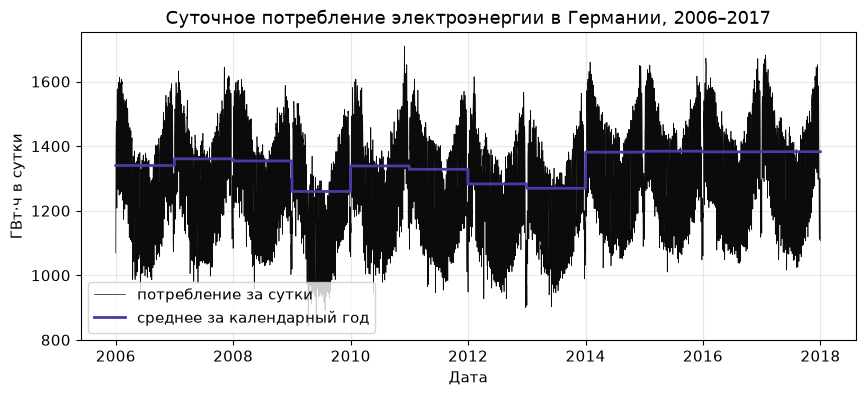

In [4]:
year_mean = y.groupby(y.index.year).transform('mean')
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y.index, y, color=COLORS['факт'], lw=0.5, label='потребление за сутки')
ax.plot(y.index, year_mean, color=COLORS['доп'], lw=2, label='среднее за календарный год')
ax.set_title('Суточное потребление электроэнергии в Германии, 2006–2017')
ax.set_xlabel('Дата')
ax.set_ylabel('ГВт·ч в сутки')
ax.legend(loc='lower left')
fig.savefig('Рисунки/01_ряд_целиком.png', dpi=200, bbox_inches='tight')
plt.show()

На графике видны две закономерности. Первая — годовая волна: зимой потребление выше, летом ниже, и так каждый
год. Вторая — частые «зубцы» вниз: это недельный цикл, его лучше видно на графике одного года ниже. Среднегодовой
уровень (фиолетовая линия) не растёт и не падает монотонно, а меняется ступенями — числа в таблице ниже.

In [5]:
year_stats = y.groupby(y.index.year).agg(['mean', 'min', 'max'])
year_stats.columns = ['среднее', 'минимум', 'максимум']
year_stats['изменение среднего'] = year_stats['среднее'].diff()
year_stats.index.name = 'год'
year_stats.round(1).to_csv('Результаты/годовая_статистика.csv', encoding='utf-8')
display(year_stats.round(1))

,среднее,минимум,максимум,изменение среднего
год,,,,
2006,1339.9,955.4,1613.3,NaN
2007,1360.6,973.0,1644.9,20.7
2008,1354.0,957.0,1606.3,-6.6
2009,1259.6,842.4,1538.9,-94.5
2010,1338.6,944.9,1709.6,79.0
2011,1328.3,946.1,1607.3,-10.3
2012,1283.0,899.8,1615.1,-45.3
2013,1269.4,902.9,1563.8,-13.6
2014,1381.3,1022.5,1660.0,111.9


Монотонного тренда нет. Средний уровень держится на 1339,9–1360,6 ГВт·ч в 2006–2008 гг., в 2009 г. падает
на 94,5 ГВт·ч до минимума 1259,6, в 2012–2013 гг. снова снижен (1283,0 и 1269,4), а в 2014 г. скачком вырастает
на 111,9 ГВт·ч до 1381,3 и дальше почти не меняется (1381,3–1384,3 в 2014–2017 гг.). Причины этих изменений
в данных не указаны, поэтому в работе они рассматриваются просто как изменения уровня ряда. Для модели важно,
что тестовый 2017 год (1382,8) находится на уровне последних лет обучающей выборки.

### 1.3. Сезонность и выбросы

Календарь общегерманских праздников берётся из библиотеки `holidays` (без праздников отдельных земель).
Ниже один год ряда показан крупно, праздничные дни отмечены точками.

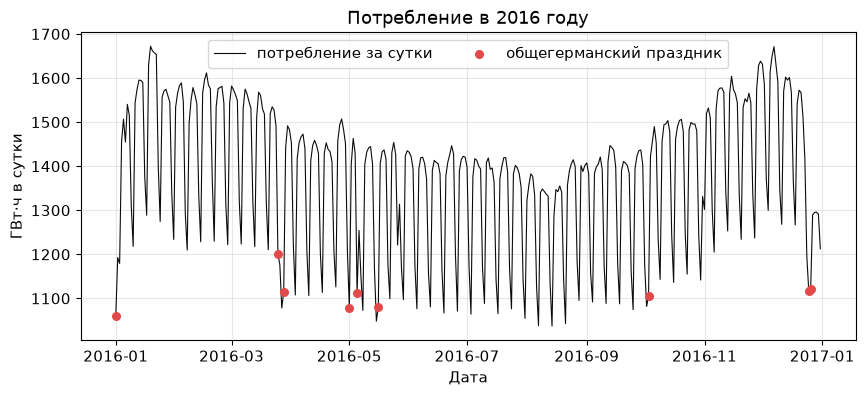

In [6]:
hol = holidays.Germany(years=range(2006, 2018))
hol_days = pd.DatetimeIndex(list(hol.keys()))

one_year = y.loc['2016']
one_year_hol = one_year[one_year.index.isin(hol_days)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(one_year.index, one_year, color=COLORS['факт'], lw=0.8, label='потребление за сутки')
ax.scatter(one_year_hol.index, one_year_hol, color=COLORS['праздник'], s=30, zorder=3,
           label='общегерманский праздник')
ax.set_title('Потребление в 2016 году')
ax.set_xlabel('Дата')
ax.set_ylabel('ГВт·ч в сутки')
ax.legend(loc='upper center', ncol=2)
fig.savefig('Рисунки/02_один_год.png', dpi=200, bbox_inches='tight')
plt.show()

На одном году недельный цикл виден отчётливо: пять высоких рабочих дней и провал в субботу и воскресенье,
а годовая волна плавно поднимает и опускает весь этот рисунок. Общегерманские праздники
(красные точки) лежат на уровне воскресений, хотя многие из них приходятся на будние дни. В конце декабря
потребление остаётся низким несколько дней подряд, а не только в праздники 25–26 декабря.

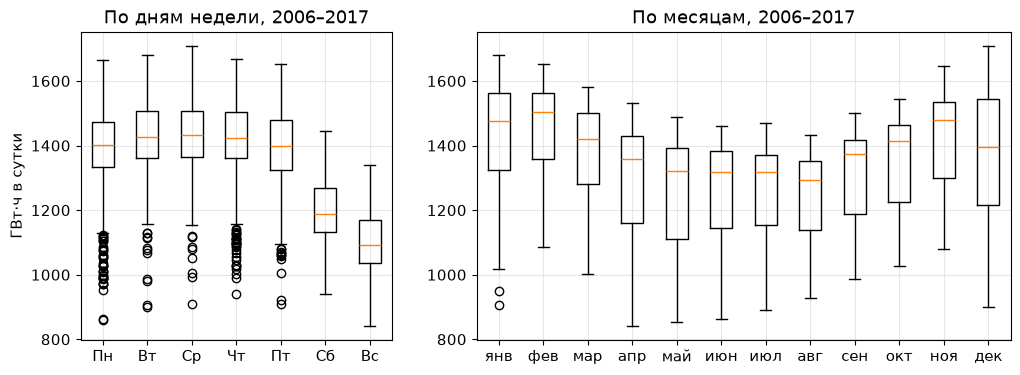

,Пн,Вт,Ср,Чт,Пт,Сб,Вс
"медиана, ГВт·ч",1401.0,1427.2,1431.5,1424.9,1399.4,1187.0,1092.9


,янв,фев,мар,апр,май,июн,июл,авг,сен,окт,ноя,дек
"медиана, ГВт·ч",1476.6,1503.5,1421.3,1358.8,1320.9,1316.8,1319.3,1291.9,1373.1,1412.6,1477.8,1394.5


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [7, 12]})
axes[0].boxplot([y[y.index.dayofweek == d] for d in range(7)], tick_labels=DAYS)
axes[0].set_title('По дням недели, 2006–2017')
axes[0].set_ylabel('ГВт·ч в сутки')
axes[1].boxplot([y[y.index.month == m] for m in range(1, 13)], tick_labels=MONTHS)
axes[1].set_title('По месяцам, 2006–2017')
fig.savefig('Рисунки/03_ящики_дни_месяцы.png', dpi=200, bbox_inches='tight')
plt.show()

median_dow = y.groupby(y.index.dayofweek).median()
median_dow.index = DAYS
median_month = y.groupby(y.index.month).median()
median_month.index = MONTHS
median_dow.round(1).to_csv('Результаты/медианы_по_дням_недели.csv', encoding='utf-8')
median_month.round(1).to_csv('Результаты/медианы_по_месяцам.csv', encoding='utf-8')
display(median_dow.round(1).to_frame('медиана, ГВт·ч').T)
display(median_month.round(1).to_frame('медиана, ГВт·ч').T)

**Недельная сезонность.** Медианы рабочих дней близки (1399,4–1431,5 ГВт·ч), суббота ниже (1187,0), воскресенье
ниже всех (1092,9): разница медиан среды и воскресенья — 338,6 ГВт·ч. **Годовая сезонность.** Максимум медианы —
в феврале (1503,5), высокие значения в январе и ноябре (1476,6 и 1477,8), минимум — в августе (1291,9); декабрь
(1394,5) ниже ноября. Внутри каждого месяца разброс большой («ящики» длинные), потому что в один месяц попадают и
рабочие дни, и выходные. Кружки на графике по дням недели — значения ниже нижнего «уса», то есть необычно низкие
для своего дня недели; все они приходятся на будние дни. Какие это даты — в следующей ячейке.

In [8]:
weekdays_only = y[y.index.dayofweek < 5]
low = weekdays_only.nsmallest(15).to_frame('потребление')
low['день недели'] = [DAYS[d] for d in low.index.dayofweek]
low['праздник'] = [hol.get(d, '—') for d in low.index]
low.round(1).to_csv('Результаты/низкие_будние_дни.csv', encoding='utf-8')
display(low.round(1))

weekday = y.index.dayofweek < 5
is_hol = y.index.isin(hol_days)
xmas = (y.index.month == 12) & (y.index.day >= 24)
day_type = np.select([is_hol & weekday, xmas & weekday, y.index.dayofweek == 5, y.index.dayofweek == 6],
                     ['праздник в будний день', '24–31 декабря, будний день', 'суббота', 'воскресенье'],
                     default='обычный будний день')
by_type = y.groupby(day_type).agg(['count', 'mean', 'median'])
by_type.columns = ['дней', 'среднее', 'медиана']
by_type = by_type.sort_values('среднее', ascending=False)
by_type.round(1).to_csv('Результаты/уровень_по_типам_дней.csv', encoding='utf-8')
display(by_type.round(1))

,потребление,день недели,праздник
Date,,,
2009-04-13,860.5,Пн,Ostermontag
2009-06-01,862.6,Пн,Pfingstmontag
2012-12-25,899.8,Вт,Erster Weihnachtstag
2013-01-01,906.9,Вт,Neujahr
2012-12-26,909.6,Ср,Zweiter Weihnachtstag
2009-05-01,910.1,Пт,Erster Mai
2009-04-10,922.4,Пт,Karfreitag
2009-05-21,939.4,Чт,Christi Himmelfahrt
2013-05-20,952.7,Пн,Pfingstmontag


,дней,среднее,медиана
обычный будний день,2988,1427.9,1423.0
"24–31 декабря, будний день",50,1209.8,1209.8
суббота,626,1200.5,1187.0
воскресенье,627,1103.1,1092.9
праздник в будний день,92,1057.5,1069.5


Из 15 самых низких будних дней 14 — общегерманские праздники (Пасхальный и Троицын понедельник, Рождество,
Новый год, 1 мая, Страстная пятница, Вознесение); пятнадцатый — понедельник 31.12.2012, канун Нового года.
Средний уровень праздников, выпавших на будни, — 1057,5 ГВт·ч (92 дня): это ниже среднего воскресенья (1103,1)
и на 370,4 ГВт·ч ниже обычного будня (1427,9). Будние дни 24–31 декабря (50 дней) в среднем на уровне субботы:
1209,8 против 1200,5. Значит, выбросы ряда — праздники и последняя неделя декабря, а не ошибки данных; их не
удаляют, а учитывают признаком «праздник».

**Вывод по пункту 1.**
- **Тренд:** монотонного тренда нет, есть изменения среднегодового уровня: минимум 1259,6 ГВт·ч в 2009 г.,
  скачок на +111,9 ГВт·ч в 2014 г., с 2014 по 2017 г. уровень стабилен (1381,3–1384,3).
- **Сезонность:** недельная (медианы будних дней 1399,4–1431,5, субботы 1187,0, воскресенья 1092,9 ГВт·ч) и
  годовая (медиана февраля 1503,5 против 1291,9 в августе). Суточной сезонности в этих данных быть не может:
  шаг ряда — сутки.
- **Выбросы:** праздники и будние дни 24–31 декабря — потребление на уровне выходных; ошибок данных (пропусков,
  повторов, нулей) нет.

## 2. Признаки только из прошлого

Прогноз на день $t$ делается в конце дня $t-1$: известны значения ряда $y_1, \dots, y_{t-1}$ и календарь
(дни недели и праздники известны заранее на годы вперёд). Значение $y_t$ и всё, что после него, в признаки
дня $t$ попадать не должно — иначе модель на проверке «подсматривает» ответ, а в реальном прогнозе таких
данных не будет (утечка данных из будущего).

Какие лаги брать, видно по автокорреляции — корреляции ряда с самим собой, сдвинутым на $k$ дней.
Она считается только по обучающей части ряда (2006–2016), чтобы выбор признаков не зависел от тестового года.

"лаг, дней",1,2,3,6,7,8,14,21,28,182,364,365
автокорреляция,0.589,0.166,0.048,0.51,0.845,0.485,0.769,0.743,0.719,0.392,0.75,0.446


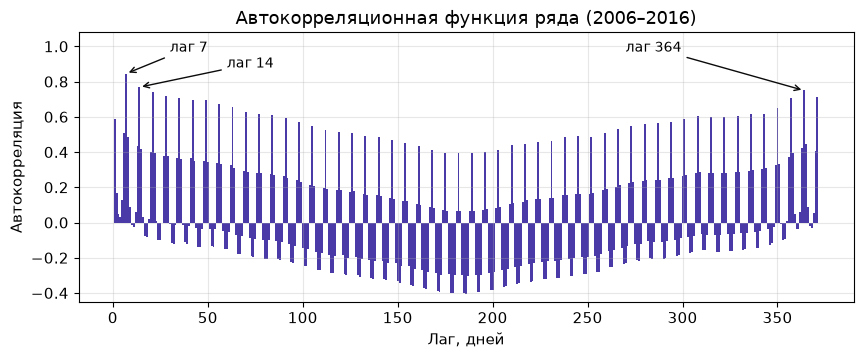

In [9]:
r = acf(y.loc[:'2016-12-31'], nlags=371)
acf_values = pd.Series({k: r[k] for k in [1, 2, 3, 6, 7, 8, 14, 21, 28, 182, 364, 365]}, name='автокорреляция')
acf_values.index.name = 'лаг, дней'
acf_values.round(3).to_csv('Результаты/автокорреляция.csv', encoding='utf-8')
display(acf_values.round(3).to_frame().T)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(1, 372), r[1:], width=1.0, color=COLORS['доп'])
for k, xy_text in {7: (30, 0.97), 14: (60, 0.88), 364: (270, 0.97)}.items():
    ax.annotate(f'лаг {k}', xy=(k, r[k]), xytext=xy_text, fontsize=10,
                arrowprops={'arrowstyle': '->', 'color': COLORS['факт']})
ax.set_ylim(-0.45, 1.08)
ax.set_xlabel('Лаг, дней')
ax.set_ylabel('Автокорреляция')
ax.set_title('Автокорреляционная функция ряда (2006–2016)')
fig.savefig('Рисунки/04_автокорреляция.png', dpi=200, bbox_inches='tight')
plt.show()

Автокорреляция подтверждает недельный цикл: на лаге 7 она максимальна (0,845), на лагах 14, 21, 28 тоже высокая
(0,769; 0,743; 0,719), а на лагах 2 и 3 почти нулевая (0,166 и 0,048) и снова растёт к лагу 6 (0,51). То есть
день похож на тот же день прошлой недели больше, чем на вчерашний (лаг 1 — 0,589). Огибающая графика опускается
к середине года и снова поднимается к году — это годовая сезонность. На лаге 364 автокорреляция 0,75, а на
лаге 365 — только 0,446: сравнивать нужно с тем же днём недели год назад. Отсюда набор лагов: 1–7 (последняя
неделя), 14, 21, 28 (тот же день недели на предыдущих неделях) и 364.

Признаки строит одна функция `make_features`. Она же используется и для обучения, и для рекурсивного
прогноза в разделе 4, поэтому признаки в обоих случаях считаются одинаково.

| Группа | Признаки | Что значит для дня $t$ |
|---|---|---|
| календарные | `день_недели` (0 = Пн … 6 = Вс), `месяц`, `год`, `выходной` (Сб, Вс), `праздник` | календарь самого дня $t$ — известен заранее |
| | `праздник_вчера`, `праздник_неделю_назад` | был ли праздником день $t-1$ / $t-7$: тогда лаг 1 / лаг 7 занижен |
| лаги | `лаг_1` … `лаг_7`, `лаг_14`, `лаг_21`, `лаг_28` | $y_{t-k}$ — значение $k$ дней назад |
| сезонные | `лаг_7` (неделю назад), `лаг_364` (год назад, тот же день недели) | $y_{t-7}$, $y_{t-364}$ |
| скользящие | `среднее_7`, `медиана_7`, `стд_7`, `мин_7`, `макс_7` и то же за 30 дней | статистика по дням $t-w, \dots, t-1$ |

Скользящие статистики считаются по ряду, сдвинутому на 1 день (`shift(1).rolling(w)`): без сдвига окно
включало бы сам день $t$. Лаг 364, а не 365, выбран потому, что $364 = 52 \cdot 7$ — год назад приходится
на тот же день недели.

In [10]:
def make_features(y):
    X = pd.DataFrame(index=y.index)
    X['день_недели'] = y.index.dayofweek
    X['месяц'] = y.index.month
    X['год'] = y.index.year
    X['выходной'] = (y.index.dayofweek >= 5).astype(int)
    X['праздник'] = y.index.isin(hol_days).astype(int)
    X['праздник_вчера'] = (y.index - pd.Timedelta(days=1)).isin(hol_days).astype(int)
    X['праздник_неделю_назад'] = (y.index - pd.Timedelta(days=7)).isin(hol_days).astype(int)
    for k in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28, 364]:
        X['лаг_' + str(k)] = y.shift(k)
    past = y.shift(1)
    for w in [7, 30]:
        X['среднее_' + str(w)] = past.rolling(w).mean()
        X['медиана_' + str(w)] = past.rolling(w).median()
        X['стд_' + str(w)] = past.rolling(w).std()
        X['мин_' + str(w)] = past.rolling(w).min()
        X['макс_' + str(w)] = past.rolling(w).max()
    return X

In [11]:
X_all = make_features(y)
print('Число признаков:', X_all.shape[1])
print('Факт за 26.12.2016–02.01.2017:')
display(y.loc['2016-12-26':'2017-01-02'].round(1).to_frame('y').T)
display(X_all.loc['2017-01-01':'2017-01-03'].round(1).T)

Число признаков: 28
Факт за 26.12.2016–02.01.2017:


Date,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,2017-01-01,2017-01-02
y,1121.2,1289.3,1294.9,1295.9,1291.0,1212.6,1130.4,1441.1


Date,2017-01-01,2017-01-02,2017-01-03
день_недели,6.0,0.0,1.0
месяц,1.0,1.0,1.0
год,2017.0,2017.0,2017.0
выходной,1.0,0.0,0.0
праздник,1.0,0.0,0.0
праздник_вчера,0.0,1.0,0.0
праздник_неделю_назад,1.0,1.0,0.0
лаг_1,1212.6,1130.4,1441.1
лаг_2,1291.0,1212.6,1130.4
лаг_3,1295.9,1291.0,1212.6


Построено 28 признаков. По таблице легко проверить сдвиги: у 02.01.2017 `лаг_1` = 1130,4 — это факт 01.01.2017,
`лаг_2` = 1212,6 — факт 31.12.2016 и т. д.; `праздник_вчера` = 1, потому что 01.01 — праздник, а
`праздник_неделю_назад` = 1, потому что праздник и 26.12.2016. Скользящие окна у 01.01.2017 охватывают последние
7 и 30 дней 2016 года — только прошлое. У первых 364 дней ряда `лаг_364` не определён (NaN), эти строки ниже
удаляются.

**Проверка отсутствия утечки.** Если признаки дня $t$ зависят только от прошлого, то изменение значения
$y_{t_0}$ не должно менять ни одного признака в дни $t \le t_0$ — только в последующие дни. Проверим это
прямо: увеличим потребление 15.06.2016 на 1000 ГВт·ч, заново построим признаки и сравним с исходными.
Изменённым считается значение признака, которое отличается от исходного больше чем на $10^{-6}$ (пропуски NaN при
таком сравнении считаются неизменными).

In [12]:
t0 = pd.Timestamp('2016-06-15')
y_changed = y.copy()
y_changed[t0] += 1000
X_changed = make_features(y_changed)
changed = (X_changed - X_all).abs() > 1e-6

rows = []
for shift in [-1, 0, 1, 7, 30, 31, 364, 365]:
    day = t0 + pd.Timedelta(days=shift)
    names = list(changed.columns[changed.loc[day].values])
    rows.append({'день': day.date(), 'дней после t0': shift, 'изменилось признаков': len(names),
                 'какие': ', '.join(names)})
leak_check = pd.DataFrame(rows)
leak_check.to_csv('Результаты/проверка_утечки.csv', index=False, encoding='utf-8')
display(leak_check)
print('Изменённых значений признаков во все дни до t0 включительно:', int(changed.loc[:t0].values.sum()))
next_day = t0 + pd.Timedelta(days=1)
print('y(t0) =', round(y[t0], 1), '| медиана окна 7 дней у t0+1:', round(X_all.loc[next_day, 'медиана_7'], 1),
      '| медиана окна 30 дней у t0+1:', round(X_all.loc[next_day, 'медиана_30'], 1))

,день,дней после t0,изменилось признаков,какие
0,2016-06-14,-1,0,
1,2016-06-15,0,0,
2,2016-06-16,1,7,"лаг_1, среднее_7, стд_7, макс_7, среднее_30, с..."
3,2016-06-22,7,7,"лаг_7, среднее_7, стд_7, макс_7, среднее_30, с..."
4,2016-07-15,30,3,"среднее_30, стд_30, макс_30"
5,2016-07-16,31,0,
6,2017-06-14,364,1,лаг_364
7,2017-06-15,365,0,


Изменённых значений признаков во все дни до t0 включительно: 0
y(t0) = 1408.3 | медиана окна 7 дней у t0+1: 1390.9 | медиана окна 30 дней у t0+1: 1406.3


В день $t_0$ = 15.06.2016 и накануне не изменился ни один признак, а всего во все дни до $t_0$ включительно —
0 изменённых значений: признаки не используют ни $y_t$ того же дня, ни будущее. Изменения появляются только
после $t_0$: на следующий день — `лаг_1` и статистики окон 7 и 30 дней, через 7 дней — `лаг_7` и окна, через
30 дней — только окно 30 дней, через 364 дня — `лаг_364`; на 31-й и 365-й день влияние заканчивается. Медиана
и минимум окон не изменились, потому что 15.06.2016 и до изменения было выше медиан обоих окон (1408,3 против
1390,9 и 1406,3), а рост значения, лежащего выше медианы, не меняет ни медиану, ни минимум. Утечки нет.

In [13]:
data = X_all.copy()
data['y'] = y
print('Строк с пропусками в признаках:', data.isna().any(axis=1).sum())
data = data.dropna()
print('Осталось строк:', len(data), '| первая дата:', data.index.min().date())

Строк с пропусками в признаках: 364
Осталось строк: 4019 | первая дата: 2006-12-31


Удалены 364 первые строки (01.01–30.12.2006), для которых нет значения год назад. Для моделирования осталось
4019 дней — с 31.12.2006 по 31.12.2017.

## 3. Разделение и кросс-валидация по времени

Ряд делится по времени, без перемешивания: обучение — 2006–2016 гг., тест — весь 2017 год. Тестом взят
целый последний год, чтобы в нём были все месяцы и все праздники, то есть вся годовая сезонность.

In [14]:
features = list(X_all.columns)
train = data[data.index.year <= 2016]
test = data[data.index.year == 2017]
X_train, y_train = train[features], train['y']
X_test, y_test = test[features], test['y']
print('train:', X_train.index.min().date(), '—', X_train.index.max().date(), '|', len(X_train), 'дней')
print('test: ', X_test.index.min().date(), '—', X_test.index.max().date(), '|', len(X_test), 'дней')
print('Все дни train раньше всех дней test:', X_train.index.max() < X_test.index.min())

train: 2006-12-31 — 2016-12-31 | 3654 дней
test:  2017-01-01 — 2017-12-31 | 365 дней
Все дни train раньше всех дней test: True


Train — 3654 дня (31.12.2006–31.12.2016), test — 365 дней 2017 года, это примерно 91 % и 9 % строк. Все дни
обучения раньше всех дней теста. При случайном перемешивании модель училась бы на днях, которые идут после
проверяемых, и знала бы их соседей с обеих сторон; оценка получилась бы оптимистичнее, чем реальный прогноз
будущего, в котором следующих дней ещё нет.

Гиперпараметры подбираются только на train кросс-валидацией `TimeSeriesSplit`: каждый фолд проверки —
365 дней, обучение — все дни до него (расширяющееся окно). Для сравнения задано и скользящее окно:
`max_train_size=3*365` — обучение только на трёх последних годах перед фолдом.

In [15]:
tscv = TimeSeriesSplit(n_splits=5, test_size=365)
tscv_sliding = TimeSeriesSplit(n_splits=5, test_size=365, max_train_size=3 * 365)

rows = []
for name, cv in [('расширяющееся', tscv), ('скользящее', tscv_sliding)]:
    for k, (tr, va) in enumerate(cv.split(X_train), start=1):
        rows.append({'окно': name, 'фолд': k,
                     'обучение с': X_train.index[tr[0]].date(), 'обучение по': X_train.index[tr[-1]].date(),
                     'дней обучения': len(tr),
                     'проверка с': X_train.index[va[0]].date(), 'проверка по': X_train.index[va[-1]].date()})
folds = pd.DataFrame(rows)
folds.to_csv('Результаты/фолды.csv', index=False, encoding='utf-8')
display(folds)

,окно,фолд,обучение с,обучение по,дней обучения,проверка с,проверка по
0,расширяющееся,1,2006-12-31,2012-01-02,1829,2012-01-03,2013-01-01
1,расширяющееся,2,2006-12-31,2013-01-01,2194,2013-01-02,2014-01-01
2,расширяющееся,3,2006-12-31,2014-01-01,2559,2014-01-02,2015-01-01
3,расширяющееся,4,2006-12-31,2015-01-01,2924,2015-01-02,2016-01-01
4,расширяющееся,5,2006-12-31,2016-01-01,3289,2016-01-02,2016-12-31
5,скользящее,1,2009-01-03,2012-01-02,1095,2012-01-03,2013-01-01
6,скользящее,2,2010-01-03,2013-01-01,1095,2013-01-02,2014-01-01
7,скользящее,3,2011-01-03,2014-01-01,1095,2014-01-02,2015-01-01
8,скользящее,4,2012-01-03,2015-01-01,1095,2015-01-02,2016-01-01
9,скользящее,5,2013-01-02,2016-01-01,1095,2016-01-02,2016-12-31


Пять фолдов проверки по 365 дней покрывают 2012–2016 годы. Границы сдвинуты на 1–2 дня от 1 января, потому что
фолды отсчитываются по 365 дней от конца train, а 2012 и 2016 годы високосные. В расширяющемся окне обучение
каждый раз начинается с 31.12.2006 и растёт с 1829 до 3289 дней; в скользящем — всегда 1095 дней (3 года)
непосредственно перед фолдом.

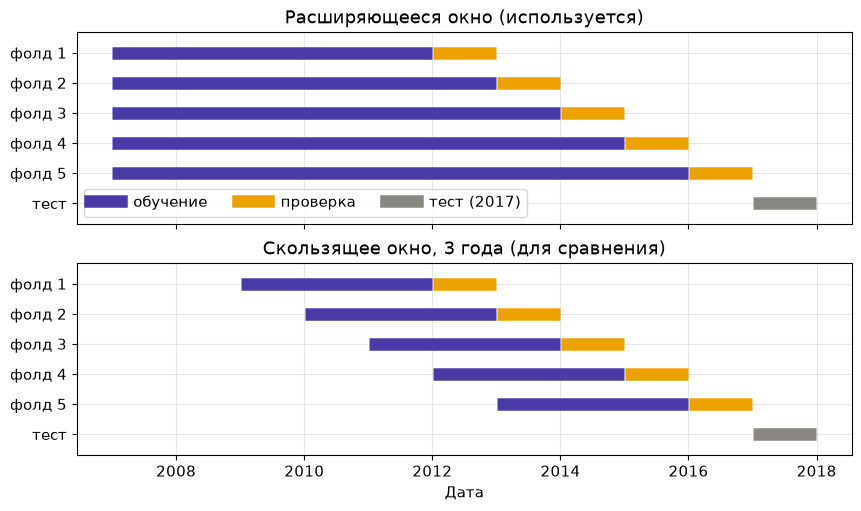

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ax, (name, cv) in zip(axes, [('Расширяющееся окно (используется)', tscv),
                                 ('Скользящее окно, 3 года (для сравнения)', tscv_sliding)]):
    for k, (tr, va) in enumerate(cv.split(X_train), start=1):
        ax.hlines(k, X_train.index[tr[0]], X_train.index[tr[-1]], colors=COLORS['доп'], lw=9)
        ax.hlines(k, X_train.index[va[0]], X_train.index[va[-1]], colors='#eda100', lw=9)
    ax.hlines(6, X_test.index[0], X_test.index[-1], colors=COLORS['Наивный'], lw=9)
    ax.set_yticks(range(1, 7), [f'фолд {k}' for k in range(1, 6)] + ['тест'])
    ax.set_ylim(6.7, 0.3)
    ax.set_title(name)
axes[0].plot([], [], color=COLORS['доп'], lw=9, label='обучение')
axes[0].plot([], [], color='#eda100', lw=9, label='проверка')
axes[0].plot([], [], color=COLORS['Наивный'], lw=9, label='тест (2017)')
axes[0].legend(loc='lower left', ncol=3)
axes[1].set_xlabel('Дата')
fig.savefig('Рисунки/05_фолды.png', dpi=200, bbox_inches='tight')
plt.show()

На схеме обучение (фиолетовое) всегда левее проверки (жёлтой), а тестовый 2017 год (серый) не входит ни в один
фолд: он используется один раз, для итоговой оценки. В скользящем окне старые годы постепенно выпадают из
обучения.

## 4. Модель прогноза на 1 шаг и прогноз на горизонт H

### 4.1. Простые эталоны

Чтобы было с чем сравнивать, нужны два простейших прогноза: наивный «как вчера» $\hat y_t = y_{t-1}$ и
сезонно-наивный «как неделю назад» $\hat y_t = y_{t-7}$. Модель имеет смысл, только если она заметно точнее
их. Качество на кросс-валидации измеряется средней абсолютной ошибкой MAE в ГВт·ч (формулы всех метрик —
в разделе 5). Функция `baseline_cv` считает MAE эталона на каждом фолде проверки; прогноз эталона — это уже
готовый столбец признаков `лаг_1` или `лаг_7`.

In [17]:
fold_names = [f'фолд {k} ({X_train.index[va[0]].year})' for k, (tr, va) in enumerate(tscv.split(X_train), start=1)]

def baseline_cv(column):
    return [mean_absolute_error(y_train.iloc[va], X_train[column].iloc[va]) for tr, va in tscv.split(X_train)]

cv_mae = pd.DataFrame({'Наивный': baseline_cv('лаг_1'), 'Сезонно-наивный': baseline_cv('лаг_7')}, index=fold_names)
display(cv_mae.round(2))
print('Среднее по фолдам:', cv_mae.mean().round(2).to_dict())

,Наивный,Сезонно-наивный
фолд 1 (2012),106.57,61.36
фолд 2 (2013),98.81,54.44
фолд 3 (2014),104.91,48.83
фолд 4 (2015),102.14,45.73
фолд 5 (2016),102.28,47.95


Среднее по фолдам: {'Наивный': 102.94, 'Сезонно-наивный': 51.66}


Наивный прогноз ошибается в среднем на 102,94 ГВт·ч (98,81–106,57 по фолдам): «как вчера» плохо работает при
недельном цикле — понедельник прогнозируется по воскресенью, а суббота по пятнице. Сезонно-наивный «как неделю
назад» вдвое точнее: 51,66 ГВт·ч (45,73–61,36). Модели должны заметно обогнать именно его.

### 4.2. Гребневая регрессия (Ridge)

День недели и месяц — категории, линейной модели их нужно подать в виде one-hot (отдельный столбец 0/1 на
каждое значение). Иначе модель считала бы, что потребление меняется равномерно от понедельника (0) к воскресенью
(6), хотя на деле пять будней почти одинаковы, а провал приходится на выходные. Остальные признаки
стандартизуются: у Ridge штраф $\alpha \sum w_j^2$ одинаков для всех коэффициентов, поэтому признаки
должны быть в одном масштабе. Оба преобразования стоят внутри `Pipeline`, поэтому на каждом фолде они
обучаются только на его обучающей части. Функция `make_ridge` собирает такой конвейер для заданного списка
числовых признаков (в разделе 6 он понадобится ещё раз, с добавленными STL-признаками).

In [18]:
cat_features = ['день_недели', 'месяц']
num_features = [f for f in features if f not in cat_features]

def make_ridge(num_cols):
    prep = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
                              ('num', StandardScaler(), num_cols)])
    return Pipeline([('prep', prep), ('model', Ridge())])

ridge_grid = GridSearchCV(make_ridge(num_features), {'model__alpha': np.logspace(-3, 3, 13)},
                          cv=tscv, scoring='neg_mean_absolute_error')
ridge_grid.fit(X_train, y_train)
print('Лучшее alpha:', ridge_grid.best_params_['model__alpha'])
print('MAE на кросс-валидации:', round(-ridge_grid.best_score_, 2))

Лучшее alpha: 0.001
MAE на кросс-валидации: 22.57


Перебрано 13 значений $\alpha$ от 0,001 до 1000 (равномерно по логарифмической шкале), для каждого — 5 фолдов.
Лучшее $\alpha = 0{,}001$, средняя MAE на кросс-валидации — 22,57 ГВт·ч, то есть в 2,3 раза меньше, чем у
сезонно-наивного прогноза (51,66). Как MAE зависит от $\alpha$, показано ниже.

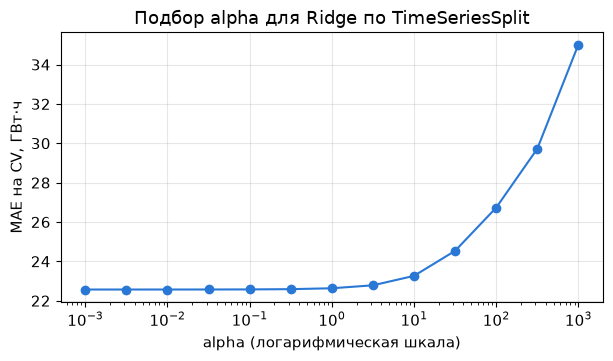

,0,1,2,3,4,5,6,7,8,9,10,11,12
alpha,0.001,0.003,0.010,0.032,0.100,0.316,1.000,3.162,10.000,31.623,100.000,316.228,1000.000
MAE на CV,22.568,22.568,22.568,22.570,22.573,22.587,22.632,22.782,23.262,24.534,26.729,29.722,35.019
std по фолдам,2.415,2.415,2.415,2.415,2.415,2.415,2.418,2.443,2.572,3.161,3.990,4.721,5.943


In [19]:
alpha_curve = pd.DataFrame({'alpha': ridge_grid.cv_results_['param_model__alpha'].astype(float),
                            'MAE на CV': -ridge_grid.cv_results_['mean_test_score'],
                            'std по фолдам': ridge_grid.cv_results_['std_test_score']})
alpha_curve.to_csv('Результаты/ridge_alpha.csv', index=False, encoding='utf-8')
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogx(alpha_curve['alpha'], alpha_curve['MAE на CV'], marker='o', color=COLORS['Ridge'])
ax.set_xlabel('alpha (логарифмическая шкала)')
ax.set_ylabel('MAE на CV, ГВт·ч')
ax.set_title('Подбор alpha для Ridge по TimeSeriesSplit')
fig.savefig('Рисунки/06_ridge_alpha.png', dpi=200, bbox_inches='tight')
plt.show()
display(alpha_curve.round(3).T)

Кривая почти плоская при $\alpha \le 0{,}1$ (MAE 22,568–22,573) и растёт при сильной регуляризации: 23,262 при
$\alpha = 10$ и 35,019 при $\alpha = 1000$ — большой штраф стягивает коэффициенты к нулю, и модель перестаёт
следовать данным. Регуляризация здесь не даёт выигрыша; при одинаковой (до третьего знака) MAE `GridSearchCV`
берёт первое значение сетки, отсюда $\alpha = 0{,}001$, и модель практически совпадает с обычной линейной
регрессией по методу наименьших квадратов.

In [20]:
best_alpha = ridge_grid.best_params_['model__alpha']
no_flags = [f for f in features if f not in ['праздник_вчера', 'праздник_неделю_назад']]
ridge_no_flags = make_ridge([f for f in no_flags if f not in cat_features]).set_params(model__alpha=best_alpha)
flags = pd.DataFrame(index=fold_names)
flags['без этих двух признаков'] = -cross_validate(ridge_no_flags, X_train[no_flags], y_train, cv=tscv,
                                                   scoring='neg_mean_absolute_error')['test_score']
flags['со всеми признаками'] = -cross_validate(ridge_grid.best_estimator_, X_train, y_train, cv=tscv,
                                               scoring='neg_mean_absolute_error')['test_score']
flags.loc['среднее'] = flags.mean()
flags.round(2).to_csv('Результаты/признаки_праздников.csv', encoding='utf-8')
display(flags.round(2))

,без этих двух признаков,со всеми признаками
фолд 1 (2012),29.32,27.23
фолд 2 (2013),24.51,22.59
фолд 3 (2014),23.48,20.95
фолд 4 (2015),22.45,21.25
фолд 5 (2016),21.90,20.83
среднее,24.33,22.57


В ячейке выше Ridge с найденным $\alpha$ сравнивается на тех же фолдах без признаков `праздник_вчера` и
`праздник_неделю_назад` и со всеми признаками. Эти два признака уменьшают MAE на всех пяти фолдах, в среднем с
24,33 до 22,57 ГВт·ч. Смысл в том, что после праздника `лаг_1` (а через неделю — `лаг_7`) занижен, и без флага модель
переносит этот провал на обычный рабочий день; флаг даёт ей возможность сделать поправку. Оба признака строятся
по календарю, поэтому утечки нет.

### 4.3. Градиентный бустинг (HistGradientBoostingRegressor)

Бустинг строит последовательность небольших деревьев решений, каждое следующее исправляет ошибки суммы
предыдущих. Деревьям не нужны ни масштабирование, ни one-hot: они делят выборку порогами по значениям
признаков. Перебираются шаг обучения `learning_rate`, число деревьев `max_iter`, размер дерева
`max_leaf_nodes` и минимальное число дней в листе `min_samples_leaf` — 36 сочетаний на тех же фолдах.

In [21]:
hgb_params = {'learning_rate': [0.05, 0.1], 'max_iter': [200, 400, 800],
              'max_leaf_nodes': [15, 31], 'min_samples_leaf': [20, 40, 80]}
hgb_grid = GridSearchCV(HistGradientBoostingRegressor(random_state=RANDOM_STATE), hgb_params,
                        cv=tscv, scoring='neg_mean_absolute_error')
hgb_grid.fit(X_train, y_train)
print('Лучшие параметры:', hgb_grid.best_params_)
print('MAE на кросс-валидации:', round(-hgb_grid.best_score_, 2))

grid_table = pd.DataFrame(hgb_grid.cv_results_['params'])
grid_table['MAE на CV'] = -hgb_grid.cv_results_['mean_test_score']
grid_table['std по фолдам'] = hgb_grid.cv_results_['std_test_score']
grid_table = grid_table.sort_values('MAE на CV').reset_index(drop=True)
grid_table.to_csv('Результаты/hgb_сетка.csv', index=False, encoding='utf-8')
display(grid_table.head(10).round(2))
print('MAE по всем 36 сочетаниям: от', round(grid_table['MAE на CV'].min(), 2),
      'до', round(grid_table['MAE на CV'].max(), 2))
display(grid_table.groupby('min_samples_leaf')['MAE на CV'].agg(['min', 'max']).round(2))

Лучшие параметры: {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 15, 'min_samples_leaf': 40}
MAE на кросс-валидации: 22.92


,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,MAE на CV,std по фолдам
0,0.05,400,15,40,22.92,4.68
1,0.05,200,15,40,23.08,4.51
2,0.10,200,15,40,23.09,4.56
3,0.05,800,15,40,23.25,4.87
4,0.10,400,15,40,23.32,4.73
5,0.05,200,31,20,23.39,5.69
6,0.05,400,15,20,23.42,5.15
7,0.05,200,31,40,23.42,4.85
8,0.10,200,15,20,23.54,4.79
9,0.05,200,15,20,23.57,4.81


MAE по всем 36 сочетаниям: от 22.92 до 31.49


,min,max
min_samples_leaf,,
20,23.39,24.24
40,22.92,24.67
80,29.08,31.49


Лучшее сочетание: `learning_rate=0.05`, `max_iter=400`, `max_leaf_nodes=15`, `min_samples_leaf=40`, средняя MAE
на кросс-валидации — 22,92 ГВт·ч. Значения 400 и 40 лежат внутри сетки: и 200, и 800 деревьев при тех же
остальных параметрах хуже (23,08 и 23,25), а `min_samples_leaf=80` резко ухудшает качество — MAE 29,08–31,49
при любых других параметрах. Разница между лучшими сочетаниями (22,92–23,09) меньше разброса MAE по фолдам
(стандартное отклонение 4,5–4,7), то есть год проверки влияет на ошибку сильнее, чем настройка гиперпараметров.

### 4.4. Сравнение моделей на кросс-валидации

Для каждой модели на каждом фолде обучается новая копия (`clone`) только на обучающей части фолда.
Кроме MAE считается средняя ошибка $\overline{\hat y - y}$ (смещение): если она заметно меньше нуля,
модель систематически занижает прогноз, если больше — завышает. `ridge_grid.best_estimator_` и
`hgb_grid.best_estimator_` — лучшие модели, которые `GridSearchCV` после подбора уже обучил заново на всём train
(параметр `refit=True` действует по умолчанию); дальше они называются `ridge` и `hgb`.

In [22]:
ridge = ridge_grid.best_estimator_
hgb = hgb_grid.best_estimator_
models = {'Ridge': ridge, 'Бустинг': hgb}

cv_bias = pd.DataFrame(index=fold_names)
for name, model in models.items():
    mae_list, bias_list = [], []
    for tr, va in tscv.split(X_train):
        fold_model = clone(model).fit(X_train.iloc[tr], y_train.iloc[tr])
        pred = fold_model.predict(X_train.iloc[va])
        mae_list.append(mean_absolute_error(y_train.iloc[va], pred))
        bias_list.append(np.mean(pred - y_train.iloc[va]))
    cv_mae[name] = mae_list
    cv_bias[name] = bias_list
cv_mae.loc['среднее'] = cv_mae.mean()
cv_bias.loc['среднее'] = cv_bias.mean()
cv_mae.round(2).to_csv('Результаты/cv_mae.csv', encoding='utf-8')
cv_bias.round(2).to_csv('Результаты/cv_смещение.csv', encoding='utf-8')
print('MAE на фолдах, ГВт·ч:')
display(cv_mae.round(2))
print('Смещение (средняя ошибка прогноз − факт), ГВт·ч:')
display(cv_bias.round(2))

MAE на фолдах, ГВт·ч:


,Наивный,Сезонно-наивный,Ridge,Бустинг
фолд 1 (2012),106.57,61.36,27.23,29.31
фолд 2 (2013),98.81,54.44,22.59,23.25
фолд 3 (2014),104.91,48.83,20.95,26.62
фолд 4 (2015),102.14,45.73,21.25,17.30
фолд 5 (2016),102.28,47.95,20.83,18.11
среднее,102.94,51.66,22.57,22.92


Смещение (средняя ошибка прогноз − факт), ГВт·ч:


,Ridge,Бустинг
фолд 1 (2012),4.92,6.18
фолд 2 (2013),-0.36,-1.86
фолд 3 (2014),-7.51,-17.65
фолд 4 (2015),10.43,3.76
фолд 5 (2016),5.09,1.28
среднее,2.51,-1.66


Обе модели примерно в 2,3 раза точнее сезонно-наивного прогноза: средняя MAE 22,57 у Ridge и 22,92 у бустинга
против 51,66. В среднем Ridge немного лучше, но по годам картина разная: в 2015 и 2016 гг. точнее бустинг (17,30
и 18,11 против 21,25 и 20,83), а в 2014 г. он заметно хуже (26,62 против 20,95). 2014 год — год скачка среднего
уровня ряда на 111,9 ГВт·ч, и смещение бустинга в этом фолде −17,65 ГВт·ч: он систематически занижал прогноз,
когда уровень вырос. У Ridge смещение в 2014 г. −7,51 ГВт·ч — к новому уровню он подстроился лучше. Разброс MAE
по фолдам у бустинга больше (17,30–29,31), чем у Ridge (20,83–27,23).

In [23]:
windows = pd.DataFrame(index=fold_names)
for name, model in models.items():
    for window, cv in [('расширяющееся', tscv), ('скользящее 3 года', tscv_sliding)]:
        windows[f'{name}: {window}'] = -cross_validate(model, X_train, y_train, cv=cv,
                                                       scoring='neg_mean_absolute_error')['test_score']
windows.loc['среднее'] = windows.mean()
windows.round(2).to_csv('Результаты/cv_окна.csv', encoding='utf-8')
display(windows.round(2))

,Ridge: расширяющееся,Ridge: скользящее 3 года,Бустинг: расширяющееся,Бустинг: скользящее 3 года
фолд 1 (2012),27.23,29.27,29.31,36.87
фолд 2 (2013),22.59,26.10,23.25,31.46
фолд 3 (2014),20.95,37.82,26.62,57.70
фолд 4 (2015),21.25,30.44,17.30,26.58
фолд 5 (2016),20.83,20.16,18.11,27.49
среднее,22.57,28.76,22.92,36.02


Скользящее окно в 3 года хуже расширяющегося у обеих моделей: средняя MAE 28,76 против 22,57 у Ridge и 36,02
против 22,92 у бустинга. Сильнее всего проигрывает фолд 2014 г. (37,82 и 57,70): в скользящем окне модель для него
обучена только на 2011–2013 гг., средний уровень которых (1269,4–1328,3 ГВт·ч) ниже уровня 2014 г. (1381,3),
а в расширяющемся окне в обучение входят и 2006–2008 гг. с уровнем 1339,9–1360,6. Поэтому дальше используется
расширяющееся окно.

### 4.5. Прогноз на 1 шаг вперёд на тестовом 2017 годе

Обе модели обучены на всём train (2006–2016). Прогноз на каждый день 2017 года делается по фактическим
значениям до предыдущего дня включительно — это прогноз «на завтра».

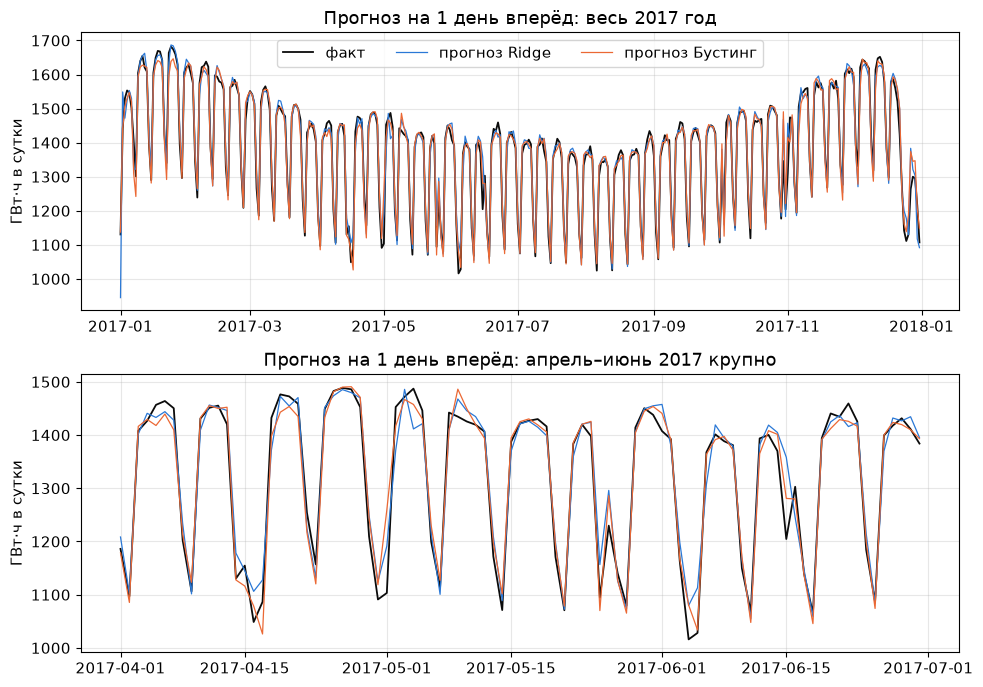

In [24]:
pred_train = pd.DataFrame({'Наивный': X_train['лаг_1'], 'Сезонно-наивный': X_train['лаг_7'],
                           'Ridge': ridge.predict(X_train), 'Бустинг': hgb.predict(X_train)}, index=X_train.index)
pred_test = pd.DataFrame({'Наивный': X_test['лаг_1'], 'Сезонно-наивный': X_test['лаг_7'],
                          'Ridge': ridge.predict(X_test), 'Бустинг': hgb.predict(X_test)}, index=X_test.index)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
for ax, (start, end, title) in zip(axes, [('2017-01-01', '2017-12-31', 'весь 2017 год'),
                                          ('2017-04-01', '2017-06-30', 'апрель–июнь 2017 крупно')]):
    ax.plot(y_test.loc[start:end], color=COLORS['факт'], lw=1.3, label='факт')
    for name in ['Ridge', 'Бустинг']:
        ax.plot(pred_test.loc[start:end, name], color=COLORS[name], lw=0.9, label=f'прогноз {name}')
    ax.set_title(f'Прогноз на 1 день вперёд: {title}')
    ax.set_ylabel('ГВт·ч в сутки')
axes[0].legend(loc='upper center', ncol=3)
fig.tight_layout()
fig.savefig('Рисунки/07_прогноз_1_шаг.png', dpi=200, bbox_inches='tight')
plt.show()

Прогноз на 1 день повторяет и недельный цикл, и годовую волну; на графике за весь год линии почти сливаются.
Заметный промах в начале года — 01.01.2017, где прогноз Ridge опускается ниже 1000 ГВт·ч. На крупном графике
видны промахи в праздничные недели: Пасха (14 и 17 апреля), 1 мая, Вознесение (25 мая) и Троица (5 июня), а
также 15 июня (праздник Тела Христова только в части земель, в признаке `праздник` его нет). Количественный
разбор ошибок — в разделе 5.

### 4.6. Рекурсивная стратегия прогноза на горизонт H

Горизонт выбран $H = 14$ дней — два недельных периода: каждый день недели входит в прогноз дважды, и видно,
как растёт ошибка по мере подстановки собственных прогнозов вместо фактических лагов. Из трёх стратегий
задания (рекурсивная, прямая, гибридная) реализована рекурсивная: одна модель на 1 шаг применяется 14 раз
подряд. Прогноз очередного дня дописывается в историю ряда, и на следующем шаге `make_features` берёт его
как `лаг_1`, а скользящие статистики пересчитываются уже с ним. Лаги 21, 28 и 364 при $H = 14$ всегда остаются
фактическими значениями.

Как устроена функция `recursive_forecast`: берётся история ряда до дня перед началом прогноза (последние 400 дней —
этого хватает для лага 364); затем 14 раз подряд в историю добавляется новый день с временным значением 0, для
него строятся признаки, модель делает прогноз, и прогноз записывается в историю вместо временного значения.
Временное значение может быть любым: признаки дня $t$ от $y_t$ не зависят (это проверено в разделе 2). Флаг
`use_stl=True` дополнительно добавляет STL-признаки из раздела 6. Ниже — пример прогноза от 06.03.2017.

In [25]:
def recursive_forecast(model, y_known, start, H, use_stl=False):
    history = y_known.loc[:start - pd.Timedelta(days=1)].iloc[-400:].copy()
    for h in range(H):
        day = start + pd.Timedelta(days=h)
        history.loc[day] = 0.0
        X_day = make_features(history).loc[[day]]
        if use_stl:
            X_day = X_day.join(stl_features(history, [day]))
        history.loc[day] = model.predict(X_day)[0]
    return history.loc[start:]

example_start = pd.Timestamp('2017-03-06')
example = pd.DataFrame({'факт': y.loc[example_start:example_start + pd.Timedelta(days=H - 1)]})
for name, model in models.items():
    example[name] = recursive_forecast(model, y, example_start, H)
example['ошибка Ridge'] = example['Ridge'] - example['факт']
example['ошибка Бустинг'] = example['Бустинг'] - example['факт']
example.index = [f'{d.date()} {DAYS[d.dayofweek]}' for d in example.index]
example.round(1).to_csv('Результаты/пример_рекурсии.csv', encoding='utf-8')
display(example.round(1))

,факт,Ridge,Бустинг,ошибка Ridge,ошибка Бустинг
2017-03-06 Пн,1519.8,1493.6,1504.5,-26.2,-15.3
2017-03-07 Вт,1554.9,1531.2,1538.7,-23.7,-16.1
2017-03-08 Ср,1565.2,1535.4,1546.6,-29.9,-18.6
2017-03-09 Чт,1545.1,1524.6,1540.4,-20.4,-4.6
2017-03-10 Пт,1496.8,1499.9,1515.9,3.0,19.1
2017-03-11 Сб,1265.4,1296.9,1307.8,31.5,42.4
2017-03-12 Вс,1170.7,1198.5,1197.2,27.8,26.5
2017-03-13 Пн,1478.8,1499.9,1508.8,21.0,30.0
2017-03-14 Вт,1508.4,1534.6,1528.8,26.2,20.4
2017-03-15 Ср,1497.8,1538.6,1537.9,40.8,40.1


Пример: рекурсивный прогноз от понедельника 06.03.2017 на 14 дней. После 05.03 модели не видели ни одного
фактического значения, но обе воспроизвели провалы в выходные 11–12 и 18–19 марта. Модуль ошибки не превышает
42,5 ГВт·ч у Ridge и 42,4 у бустинга — менее 3 % от уровня будней. В первую неделю Ridge занижал прогноз
с понедельника по четверг (на 20,4–29,9 ГВт·ч), а во вторую, когда лагами служат уже его собственные прогнозы,
завышал будни на 21,0–42,5. Как ошибка растёт с шагом в среднем, видно не по одному примеру, а по оценке
от 352 начал ниже.

### 4.7. Оценка на тесте со скользящим началом прогноза

Одного примера мало, поэтому прогноз на 14 дней строится от каждого дня 2017 года как от начала
(с 01.01 по 18.12, чтобы весь горизонт помещался в 2017 год) — 352 прогноза на модель. Модель при этом
не переобучается: обновляется только известная история ряда. Для эталонов на горизонте: наивный прогноз
повторяет последнее известное значение, сезонно-наивный — значения последней известной недели
($\hat y_{T+h} = y_{T+h-7(k+1)}$, $k$ — целая часть $(h-1)/7$, $T$ — последний известный день). Функция
`evaluate_horizon` строит рекурсивные прогнозы от каждой даты начала и собирает таблицу «начало — шаг — дата —
факт — прогноз», `baseline_horizon` делает то же для эталонов.

In [26]:
def evaluate_horizon(model, starts, use_stl=False):
    rows = []
    for start in starts:
        forecast = recursive_forecast(model, y, start, H, use_stl)
        for h, (day, value) in enumerate(forecast.items(), start=1):
            rows.append({'начало': start, 'шаг': h, 'дата': day, 'факт': y[day], 'прогноз': value})
    return pd.DataFrame(rows)

def baseline_horizon(starts, kind):
    rows = []
    for start in starts:
        last_day = start - pd.Timedelta(days=1)
        for h in range(1, H + 1):
            day = start + pd.Timedelta(days=h - 1)
            if kind == 'Наивный':
                value = y[last_day]
            else:
                value = y[day - pd.Timedelta(days=7 * ((h - 1) // 7 + 1))]
            rows.append({'начало': start, 'шаг': h, 'дата': day, 'факт': y[day], 'прогноз': value})
    return pd.DataFrame(rows)

test_starts = pd.date_range('2017-01-01', '2017-12-18', freq='D')
horizon_test = {name: evaluate_horizon(model, test_starts) for name, model in models.items()}
for kind in ['Наивный', 'Сезонно-наивный']:
    horizon_test[kind] = baseline_horizon(test_starts, kind)

mae_by_step = pd.DataFrame({name: (res['факт'] - res['прогноз']).abs().groupby(res['шаг']).mean()
                            for name, res in horizon_test.items()})
mae_by_step.to_csv('Результаты/mae_по_шагам.csv', encoding='utf-8')
display(mae_by_step.round(2).T)

шаг,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Ridge,19.30,23.77,25.69,27.05,28.36,28.79,29.64,30.32,30.76,31.31,32.26,32.81,33.25,33.89
Бустинг,17.69,21.75,23.93,25.62,26.81,28.12,29.20,29.69,30.22,30.71,31.75,32.05,32.70,33.50
Наивный,103.66,172.44,186.37,188.64,175.77,115.10,47.71,118.43,179.91,192.20,192.77,181.02,122.10,57.41
Сезонно-наивный,49.43,49.57,48.92,48.57,48.27,47.87,47.71,57.80,58.75,58.48,58.44,58.22,57.78,57.41


Ошибка растёт с шагом горизонта: у Ridge MAE от 19,3 ГВт·ч на 1-м шаге до 33,9 на 14-м, у бустинга — от 17,7
до 33,5. На всех 14 шагах обе модели точнее сезонно-наивного прогноза (47,7–58,8). У сезонно-наивного ошибка
ступенькой растёт после 7-го шага (с 47,7 до 57,8): на второй неделе он повторяет тот же день недели двухнедельной
давности. У наивного прогноза ошибка «пилообразная» — от 47,7 на 7-м шаге до 192,8 на 11-м: последнее известное
значение подходит только для того же дня недели.

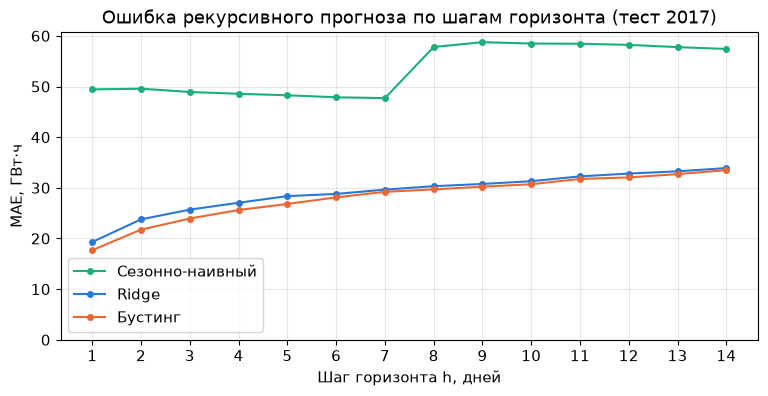

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
for name in ['Сезонно-наивный', 'Ridge', 'Бустинг']:
    ax.plot(mae_by_step.index, mae_by_step[name], marker='o', ms=4, color=COLORS[name], label=name)
ax.set_xticks(range(1, H + 1))
ax.set_xlabel('Шаг горизонта h, дней')
ax.set_ylabel('MAE, ГВт·ч')
ax.set_ylim(bottom=0)
ax.set_title('Ошибка рекурсивного прогноза по шагам горизонта (тест 2017)')
ax.legend()
fig.savefig('Рисунки/08_ошибка_по_шагам.png', dpi=200, bbox_inches='tight')
plt.show()

Быстрее всего ошибка растёт на первых шагах: с 1-го по 4-й шаг — на 7,75 ГВт·ч у Ridge (с 19,30 до 27,05) и на
7,93 у бустинга (с 17,69 до 25,62), а с 7-го по 14-й — только на 4,25 и 4,30. На первых шагах прогнозами
заменяются ближайшие лаги (сначала лаг 1, к 7-му шагу — все лаги 1–7), а лаги 21, 28, 364 и календарь до конца
горизонта остаются фактическими. Бустинг точнее Ridge на всех 14 шагах, но к 14-му шагу разница сокращается
до 0,39 ГВт·ч (33,89 против 33,50).

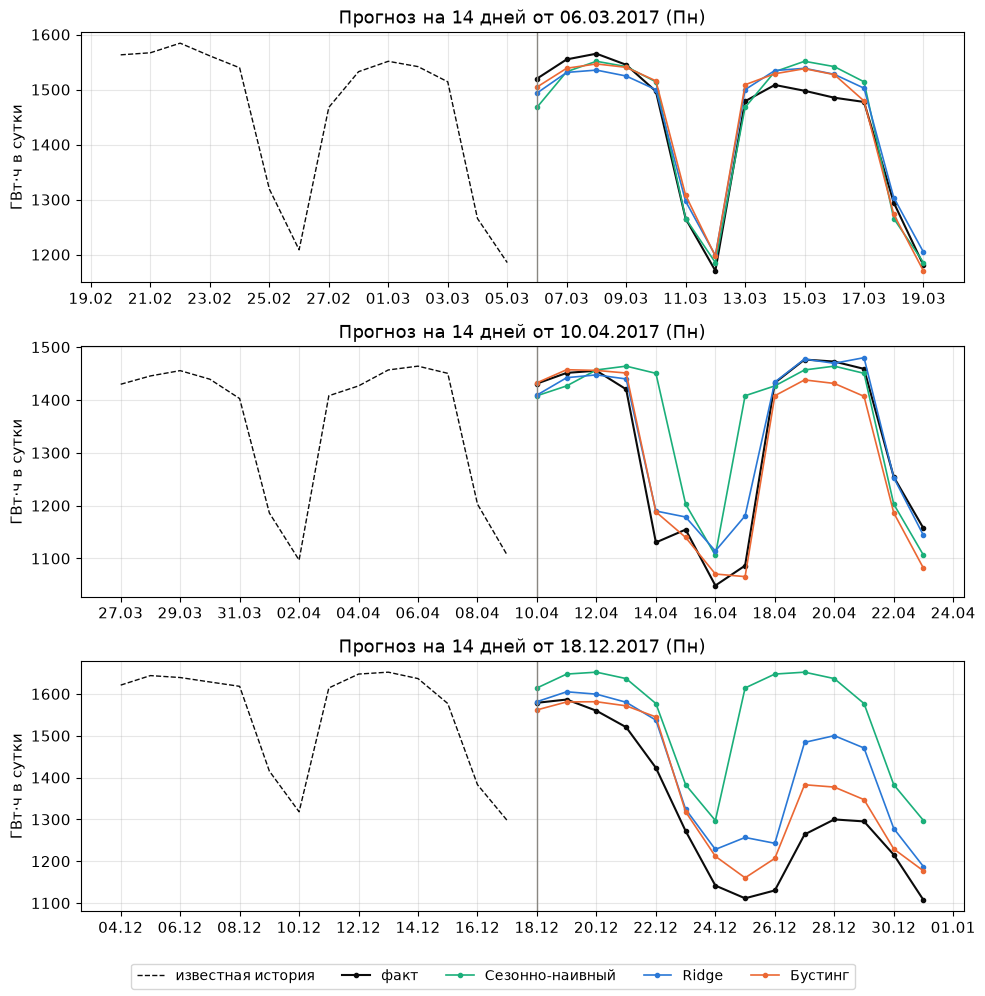

,Ridge,Бустинг,Сезонно-наивный
от 06.03.2017,25.1,22.0,24.3
от 10.04.2017,24.5,32.4,70.3
от 18.12.2017,97.8,56.5,222.1


,факт,Сезонно-наивный,Ridge,Бустинг
дата,,,,
2017-04-14,1130.3,1450.3,1189.8,1188.1
2017-04-17,1086.5,1407.9,1180.6,1065.6
2017-12-27,1263.9,1651.9,1484.0,1382.8
2017-12-28,1299.9,1636.5,1500.1,1377.2
2017-12-29,1295.1,1576.9,1470.6,1347.2


In [28]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
for ax, start in zip(axes, pd.to_datetime(['2017-03-06', '2017-04-10', '2017-12-18'])):
    before = y.loc[start - pd.Timedelta(days=14):start - pd.Timedelta(days=1)]
    after = y.loc[start:start + pd.Timedelta(days=H - 1)]
    ax.plot(before, color=COLORS['факт'], lw=1, ls='--', label='известная история')
    ax.plot(after, color=COLORS['факт'], lw=1.5, marker='o', ms=3, label='факт')
    for name in ['Сезонно-наивный', 'Ridge', 'Бустинг']:
        res = horizon_test[name]
        fc = res[res['начало'] == start].set_index('дата')['прогноз']
        ax.plot(fc, color=COLORS[name], lw=1.2, marker='.', label=name)
    ax.axvline(start, color=COLORS['Наивный'], lw=1)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.set_title(f'Прогноз на 14 дней от {start:%d.%m.%Y} ({DAYS[start.dayofweek]})')
    ax.set_ylabel('ГВт·ч в сутки')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=10)
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig('Рисунки/09_примеры_прогноза.png', dpi=200, bbox_inches='tight')
plt.show()

example_starts = pd.to_datetime(['2017-03-06', '2017-04-10', '2017-12-18'])
example_mae = pd.DataFrame({name: [(res.loc[res['начало'] == s, 'факт'] - res.loc[res['начало'] == s, 'прогноз']).abs().mean()
                                   for s in example_starts]
                            for name, res in horizon_test.items() if name != 'Наивный'},
                           index=[f'от {s:%d.%m.%Y}' for s in example_starts])
display(example_mae.round(1))
rows = []
for start, day in [('2017-04-10', '2017-04-14'), ('2017-04-10', '2017-04-17'), ('2017-12-18', '2017-12-27'),
                   ('2017-12-18', '2017-12-28'), ('2017-12-18', '2017-12-29')]:
    row = {'дата': day, 'факт': y[day]}
    for name in ['Сезонно-наивный', 'Ridge', 'Бустинг']:
        res = horizon_test[name]
        row[name] = res.loc[(res['начало'] == start) & (res['дата'] == day), 'прогноз'].iloc[0]
    rows.append(row)
example_days = pd.DataFrame(rows).set_index('дата')
example_mae.round(1).to_csv('Результаты/примеры_mae.csv', encoding='utf-8')
example_days.round(1).to_csv('Результаты/примеры_дни.csv', encoding='utf-8')
display(example_days.round(1))

Три примера; MAE каждого прогноза за 14 дней — в первой таблице. От 06.03.2017 — обычные недели: MAE 25,1 у Ridge,
22,0 у бустинга и 24,3 у сезонно-наивного прогноза, то есть без праздников простой прогноз почти так же хорош. От
10.04.2017 — пасхальная неделя: Страстная пятница 14.04 и Пасхальный понедельник 17.04. Модели предсказали провал
в эти дни по признаку `праздник` (14.04 — 1189,8 и 1188,1 при факте 1130,3), а сезонно-наивный прогноз повторил
обычную прошлую неделю и ошибся на 320,0 и 321,4 ГВт·ч; его MAE за 14 дней — 70,3 против 24,5 у Ridge и 32,4 у
бустинга. От 18.12.2017 — Рождество: модели снизили прогноз на праздничные дни, но 27–29 декабря прогноз выше факта
— у Ridge на 175,5–220,1, у бустинга на 52,1–118,9 ГВт·ч. Эти дни не праздничные, и для модели они обычные рабочие
дни декабря. MAE рождественского примера — 97,8 у Ridge, 56,5 у бустинга и 222,1 у сезонно-наивного прогноза.

## 5. Оценка качества

Пусть $y_i$ — факт, $\hat y_i$ — прогноз, $n$ — число прогнозов. Метрики:

$$\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat y_i)^2, \qquad
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat y_i|,$$

$$\mathrm{MAPE} = \frac{100\%}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat y_i}{y_i}\right|, \qquad
\mathrm{WAPE} = \frac{\sum_{i=1}^{n}|y_i - \hat y_i|}{\sum_{i=1}^{n}|y_i|}\cdot 100\%.$$

MSE измеряется в (ГВт·ч)² и сильнее всего штрафует редкие большие промахи; MAE — средний промах в ГВт·ч; MAPE —
средний промах в процентах от факта, каждый день с одинаковым весом; WAPE — сумма промахов, делённая на сумму
фактов, поэтому дни с большим потреблением весят больше. MAPE опасна, когда факт близок к нулю: деление на почти
ноль даёт огромные проценты. Здесь минимум ряда — 842,4 ГВт·ч, так что MAPE считается корректно. Функция
`metrics` считает все четыре метрики (MAPE и WAPE — в процентах).

In [29]:
def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {'MSE': mean_squared_error(y_true, y_pred),
            'MAE': mean_absolute_error(y_true, y_pred),
            'MAPE, %': mean_absolute_percentage_error(y_true, y_pred) * 100,
            'WAPE, %': np.abs(y_true - y_pred).sum() / np.abs(y_true).sum() * 100}

rows = []
for name in ['Наивный', 'Сезонно-наивный', 'Ridge', 'Бустинг']:
    rows.append({'модель': name, 'выборка': 'train 2006–2016', **metrics(y_train, pred_train[name])})
    rows.append({'модель': name, 'выборка': 'test 2017', **metrics(y_test, pred_test[name])})
metrics_1 = pd.DataFrame(rows).set_index(['модель', 'выборка'])
metrics_1.to_csv('Результаты/метрики_1_шаг.csv', encoding='utf-8')
display(metrics_1.round(2))

MSE     MAE  MAPE, %  WAPE, %
модель          выборка                                            
Наивный         train 2006–2016  22472.40  103.20     8.08     7.74
                test 2017        22248.04  102.34     7.73     7.40
Сезонно-наивный train 2006–2016   8539.42   52.00     4.07     3.90
                test 2017         9350.76   54.10     4.04     3.91
Ridge           train 2006–2016   1281.25   23.10     1.81     1.73
                test 2017          919.68   20.14     1.51     1.46
Бустинг         train 2006–2016    369.07   13.56     1.05     1.02
                test 2017          729.21   18.49     1.37     1.34

На тесте 2017 г. бустинг точнее всех: MAE 18,49 ГВт·ч, MAPE 1,37 %, WAPE 1,34 %; у Ridge — 20,14 ГВт·ч, 1,51 %
и 1,46 %. Это в 2,7–2,9 раза меньше MAE сезонно-наивного прогноза (54,10) и в 5,1–5,5 раза меньше наивного
(102,34). По MSE разрыв ещё больше (729,21 и 919,68 против 9350,76): MSE сильнее штрафует крупные промахи, а у
эталонов их много.

**Train и test.** У Ridge ошибка на train даже немного больше, чем на тесте (MAE 23,10 против 20,14), — признаков
переобучения нет. У бустинга MAE на train 13,56 против 18,49 на тесте: на обучающих данных он ошибается заметно
меньше, чем на новых, — это признак переобучения, хотя на тесте бустинг всё равно точнее Ridge. MAPE во всех
строках немного больше WAPE: относительные ошибки больше в дни с малым потреблением (праздники, выходные), а MAPE
даёт этим дням такой же вес, как будням, тогда как в WAPE их вес пропорционален потреблению.

Для горизонта те же метрики считаются по всем 14 шагам всех прогнозов. Аналог «train» здесь — 2016 год:
прогнозы от каждого дня 2016 года теми же моделями, которые этот год видели при обучении.

In [30]:
train_starts = pd.date_range('2016-01-01', '2016-12-18', freq='D')
horizon_train = {name: evaluate_horizon(model, train_starts) for name, model in models.items()}
for kind in ['Наивный', 'Сезонно-наивный']:
    horizon_train[kind] = baseline_horizon(train_starts, kind)

rows = []
for name in ['Наивный', 'Сезонно-наивный', 'Ridge', 'Бустинг']:
    for sample, res in [('train 2016', horizon_train[name]), ('test 2017', horizon_test[name])]:
        rows.append({'модель': name, 'выборка': sample, **metrics(res['факт'], res['прогноз'])})
metrics_h = pd.DataFrame(rows).set_index(['модель', 'выборка'])
metrics_h.to_csv('Результаты/метрики_горизонт.csv', encoding='utf-8')
display(metrics_h.round(2))

MSE     MAE  MAPE, %  WAPE, %
модель          выборка                                       
Наивный         train 2016  39099.39  146.22    11.09    10.56
                test 2017   38093.14  145.25    11.05    10.49
Сезонно-наивный train 2016   8199.97   49.88     3.64     3.60
                test 2017    8428.57   53.37     3.95     3.86
Ridge           train 2016   2032.75   31.53     2.34     2.28
                test 2017    1636.09   29.09     2.17     2.10
Бустинг         train 2016    903.55   20.13     1.47     1.45
                test 2017    1413.47   28.12     2.05     2.03

На горизонте 14 дней ошибки больше, чем на 1 шаг: на тесте MAE 29,09 ГВт·ч у Ridge (WAPE 2,10 %) и 28,12
у бустинга (WAPE 2,03 %) против 53,37 (3,86 %) у сезонно-наивного и 145,25 (10,49 %) у наивного прогноза, то есть
модели точнее сезонно-наивного в 1,8–1,9 раза. Соотношение train и test такое же, как для 1 шага: у Ridge ошибка
на 2016 г. больше, чем на тесте (31,53 против 29,09), у бустинга заметно меньше (20,13 против 28,12).

### 5.1. Где модель ошибается сильнее

Ошибки прогноза на 1 шаг в 2017 году разбиты по типам дней. Кроме общегерманских праздников, отдельно
выделены праздники отдельных земель (в признак `праздник` они не входят; список земель — из той же
библиотеки `holidays`, 16 земель), рабочие дни рядом с праздником (накануне или после) и период 24–31 декабря.
Функция `regional_holiday` возвращает список земель, где день — праздник, если он не общегерманский. В таблицу
крупнейших ошибок отобраны 10 дней с наибольшим средним модулем ошибки двух моделей.

In [31]:
lands = [s for s in holidays.Germany.subdivisions if len(s) == 2]
land_hol = {s: holidays.Germany(subdiv=s, years=2017) for s in lands}

def regional_holiday(day):
    if day in hol:
        return ''
    return ', '.join(s for s in lands if day in land_hol[s])

errors = pd.DataFrame({'факт': y_test,
                       'ошибка Ridge': pred_test['Ridge'] - y_test,
                       'ошибка Бустинг': pred_test['Бустинг'] - y_test})
test_days = errors.index
is_weekday = test_days.dayofweek < 5
is_hol = test_days.isin(hol_days)
is_regional = np.array([regional_holiday(d) != '' for d in test_days]) & is_weekday
near_hol = (((test_days - pd.Timedelta(days=1)).isin(hol_days) | (test_days + pd.Timedelta(days=1)).isin(hol_days))
            & is_weekday)
xmas = (test_days.month == 12) & (test_days.day >= 24)
errors['тип дня'] = np.select([is_hol, xmas, is_regional, near_hol, ~is_weekday],
                              ['общегерманский праздник', '24–31 декабря', 'праздник части земель',
                               'рабочий день рядом с праздником', 'выходной'], default='обычный рабочий день')

by_day_type = errors.groupby('тип дня').agg(дней=('факт', 'size'),
                                            MAE_Ridge=('ошибка Ridge', lambda e: e.abs().mean()),
                                            MAE_Бустинг=('ошибка Бустинг', lambda e: e.abs().mean()))
by_day_type = by_day_type.sort_values('MAE_Ridge', ascending=False)
by_day_type.round(1).to_csv('Результаты/ошибки_по_типам_дней.csv', encoding='utf-8')
display(by_day_type.round(1))

mean_abs = (errors['ошибка Ridge'].abs() + errors['ошибка Бустинг'].abs()) / 2
top = errors.loc[mean_abs.nlargest(10).index].copy()
top['день недели'] = [DAYS[d] for d in top.index.dayofweek]
top['праздник в землях'] = [regional_holiday(d) for d in top.index]
top.round(1).to_csv('Результаты/крупнейшие_ошибки.csv', encoding='utf-8')
display(top.round(1))

,дней,MAE_Ridge,MAE_Бустинг
тип дня,,,
праздник части земель,5,70.6,44.2
рабочий день рядом с праздником,10,65.8,46.1
общегерманский праздник,10,61.7,40.9
24–31 декабря,6,53.5,46.3
выходной,101,18.5,17.9
обычный рабочий день,233,15.2,15.3


,факт,ошибка Ridge,ошибка Бустинг,тип дня,день недели,праздник в землях
Date,,,,,,
2017-10-30,1345.9,122.7,144.7,рабочий день рядом с праздником,Пн,
2017-11-01,1309.2,147.7,105.6,праздник части земель,Ср,"BW, BY, NW, RP, SL"
2017-05-01,1103.2,88.1,155.9,общегерманский праздник,Пн,
2017-06-15,1204.6,153.6,76.4,праздник части земель,Чт,"BW, BY, HE, NW, RP, SL"
2017-12-27,1263.9,119.4,110.1,24–31 декабря,Ср,
2017-01-01,1130.4,-185.4,7.0,общегерманский праздник,Вс,
2017-01-07,1405.1,-82.3,-96.0,выходной,Сб,
2017-12-22,1423.2,75.2,76.4,обычный рабочий день,Пт,
2017-11-02,1474.2,-64.7,-72.6,обычный рабочий день,Чт,


Обычные рабочие дни (233) и выходные (101) прогнозируются с MAE 15,2–18,5 ГВт·ч. В особых днях ошибка
в 2,7–4,6 раза больше: праздники части земель (5 дней) — 70,6 у Ridge и 44,2 у бустинга, рабочие дни рядом
с праздником (10) — 65,8 и 46,1, общегерманские праздники (10) — 61,7 и 40,9, дни 24–31 декабря кроме праздников
25–26 декабря (6) — 53,5 и 46,3. В особых днях бустинг заметно точнее Ridge, в обычных рабочих днях они равны
(15,3 и 15,2).

Крупнейшие ошибки в основном положительные, то есть прогноз выше факта: понедельник 30.10.2017 между выходными и
праздником 31.10 (Ridge +122,7, бустинг +144,7 ГВт·ч); 01.11 и 15.06 — праздники в Баден-Вюртемберге, Баварии,
Северном Рейне — Вестфалии, Рейнланд-Пфальце и Сааре (15.06 — ещё и в Гессене), которые не отмечены в признаке
`праздник`; 01.05 — праздник в понедельник (бустинг +155,9); 27.12 — между Рождеством и Новым годом. Модель не
знает, что такой день будет «полупраздничным». Обратный случай — 01.01.2017, воскресенье и праздник одновременно,
причём неделей раньше тоже был праздник: Ridge занизил прогноз на 185,4 ГВт·ч, а бустинг ошибся всего на 7,0.

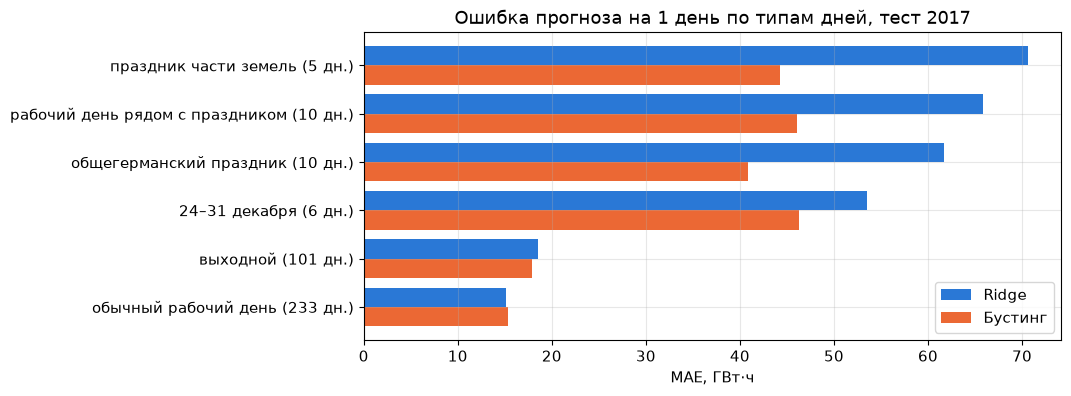

In [32]:
types = by_day_type.index[::-1]
pos = np.arange(len(types))
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(pos + 0.2, by_day_type.loc[types, 'MAE_Ridge'], height=0.4, color=COLORS['Ridge'], label='Ridge')
ax.barh(pos - 0.2, by_day_type.loc[types, 'MAE_Бустинг'], height=0.4, color=COLORS['Бустинг'], label='Бустинг')
ax.set_yticks(pos, [f'{t} ({n} дн.)' for t, n in zip(types, by_day_type.loc[types, 'дней'])])
ax.set_xlabel('MAE, ГВт·ч')
ax.set_title('Ошибка прогноза на 1 день по типам дней, тест 2017')
ax.legend(loc='lower right')
fig.savefig('Рисунки/10_ошибки_по_типам_дней.png', dpi=200, bbox_inches='tight')
plt.show()

На рисунке видно, что все четыре группы особых дней дают ошибку в несколько раз выше обычных дней, причём у Ridge
разрыв больше, чем у бустинга. Особых дней в 2017 г. 31 из 365, поэтому на итоговую MAE за год они влияют заметно:
доля этих дней — 8,5 %, а ошибки в них в 2,7–4,6 раза выше.

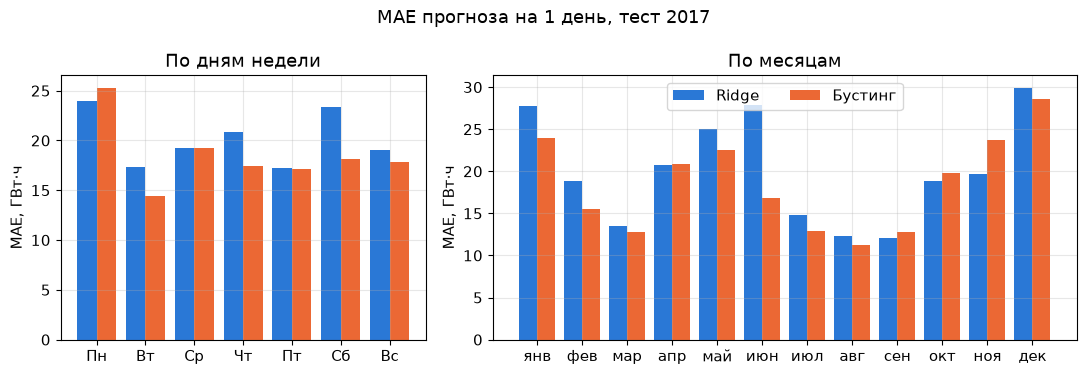

MAE по дням недели:


,Пн,Вт,Ср,Чт,Пт,Сб,Вс
ошибка Ridge,24.0,17.3,19.3,20.8,17.2,23.4,19.0
ошибка Бустинг,25.3,14.4,19.3,17.5,17.1,18.1,17.8


MAE по месяцам:


,янв,фев,мар,апр,май,июн,июл,авг,сен,окт,ноя,дек,весь год
ошибка Ridge,27.8,18.9,13.5,20.8,25.0,27.9,14.8,12.3,12.1,18.8,19.7,29.9,20.1
ошибка Бустинг,24.0,15.5,12.8,20.8,22.6,16.8,12.9,11.3,12.8,19.8,23.8,28.6,18.5


Смещение (прогноз − факт) по месяцам:


,янв,фев,мар,апр,май,июн,июл,авг,сен,окт,ноя,дек,весь год
ошибка Ridge,-1.6,5.4,4.7,3.0,3.6,10.2,8.3,2.1,4.0,4.1,2.1,-1.4,3.7
ошибка Бустинг,-19.2,3.4,0.0,-7.9,8.3,2.1,4.8,0.9,1.2,5.0,-4.8,6.2,0.0


In [33]:
abs_err = errors[['ошибка Ridge', 'ошибка Бустинг']].abs()
by_dow = abs_err.groupby(test_days.dayofweek).mean()
by_dow.index = DAYS
by_month = abs_err.groupby(test_days.month).mean()
by_month.index = MONTHS

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios': [1, 1.6]})
for ax, (table, title) in zip(axes, [(by_dow, 'По дням недели'), (by_month, 'По месяцам')]):
    x = np.arange(len(table))
    ax.bar(x - 0.2, table['ошибка Ridge'], width=0.4, color=COLORS['Ridge'], label='Ridge')
    ax.bar(x + 0.2, table['ошибка Бустинг'], width=0.4, color=COLORS['Бустинг'], label='Бустинг')
    ax.set_xticks(x, table.index)
    ax.set_ylabel('MAE, ГВт·ч')
    ax.set_title(title)
axes[1].legend(loc='upper center', ncol=2)
fig.suptitle('MAE прогноза на 1 день, тест 2017')
fig.tight_layout()
fig.savefig('Рисунки/11_ошибки_по_дням_и_месяцам.png', dpi=200, bbox_inches='tight')
plt.show()

bias_month = errors[['ошибка Ridge', 'ошибка Бустинг']].groupby(test_days.month).mean()
bias_month.index = MONTHS
by_month.loc['весь год'] = abs_err.mean()
bias_month.loc['весь год'] = errors[['ошибка Ridge', 'ошибка Бустинг']].mean()
by_dow.round(1).to_csv('Результаты/ошибки_по_дням_недели.csv', encoding='utf-8')
pd.concat([by_month.add_prefix('MAE: '), bias_month.add_prefix('смещение: ')], axis=1).round(1).to_csv(
    'Результаты/ошибки_по_месяцам.csv', encoding='utf-8')
print('MAE по дням недели:')
display(by_dow.T.round(1))
print('MAE по месяцам:')
display(by_month.T.round(1))
print('Смещение (прогноз − факт) по месяцам:')
display(bias_month.T.round(1))

По дням недели больше всего ошибок в понедельник (MAE 24,0 у Ridge и 25,3 у бустинга): в 2017 г. на понедельник
пришлись четыре общегерманских праздника (17.04, 01.05, 05.06, 25.12) и два рабочих понедельника перед
праздниками (02.10 и 30.10). По месяцам ошибки больше всего в декабре (29,9 и 28,6), январе (27,8 и 24,0), мае
(25,0 и 22,6) и у Ridge в июне (27,9), то есть в месяцах с праздниками; в марте и в июле–сентябре, где
общегерманских праздников нет, MAE 11,3–14,8 ГВт·ч. Смещение за год у Ridge +3,7 ГВт·ч (он немного завышает
прогноз в 10 месяцах из 12, сильнее всего в июне, +10,2), у бустинга 0,0; заметное занижение у бустинга только
в январе (−19,2).

**Тренд.** Средний уровень тестового 2017 г. (1382,8 ГВт·ч) почти равен уровню 2014–2016 гг. (1381,3–1384,3),
поэтому на тесте сдвига уровня нет, и смещение за год мало: +3,7 ГВт·ч у Ridge и 0,0 у бустинга, то есть не больше
0,3 % от среднего уровня. Как модели ведут себя при сдвиге уровня, показала кросс-валидация: в 2014 г. (скачок
на +111,9 ГВт·ч) смещение бустинга было −17,65 ГВт·ч, а его MAE — 26,62 против 17,30–18,11 в 2015–2016 гг.;
у Ridge смещение −7,51 и MAE 20,95. Значит, при стабильном уровне бустинг точнее, а при резком изменении уровня
устойчивее Ridge.

## 6. STL-декомпозиция

STL (Seasonal-Trend decomposition using LOESS) раскладывает ряд в сумму $y_t = T_t + S_t + R_t$: тренд,
сезонная составляющая и остаток. LOESS — локальная взвешенная регрессия: оценка в точке $t$ строится по
соседним точкам с обеих сторон. Период `period=7` — недельная сезонность; `robust=True` уменьшает вес
выбросов (праздников) при оценке тренда и сезонности.

Сила тренда и сезонности оценивается величинами
$F_T = \max\left(0,\ 1 - \frac{\mathrm{Var}(R)}{\mathrm{Var}(T+R)}\right)$ и
$F_S = \max\left(0,\ 1 - \frac{\mathrm{Var}(R)}{\mathrm{Var}(S+R)}\right)$: чем ближе к 1, тем сильнее компонента.
Их считает функция `strength`.

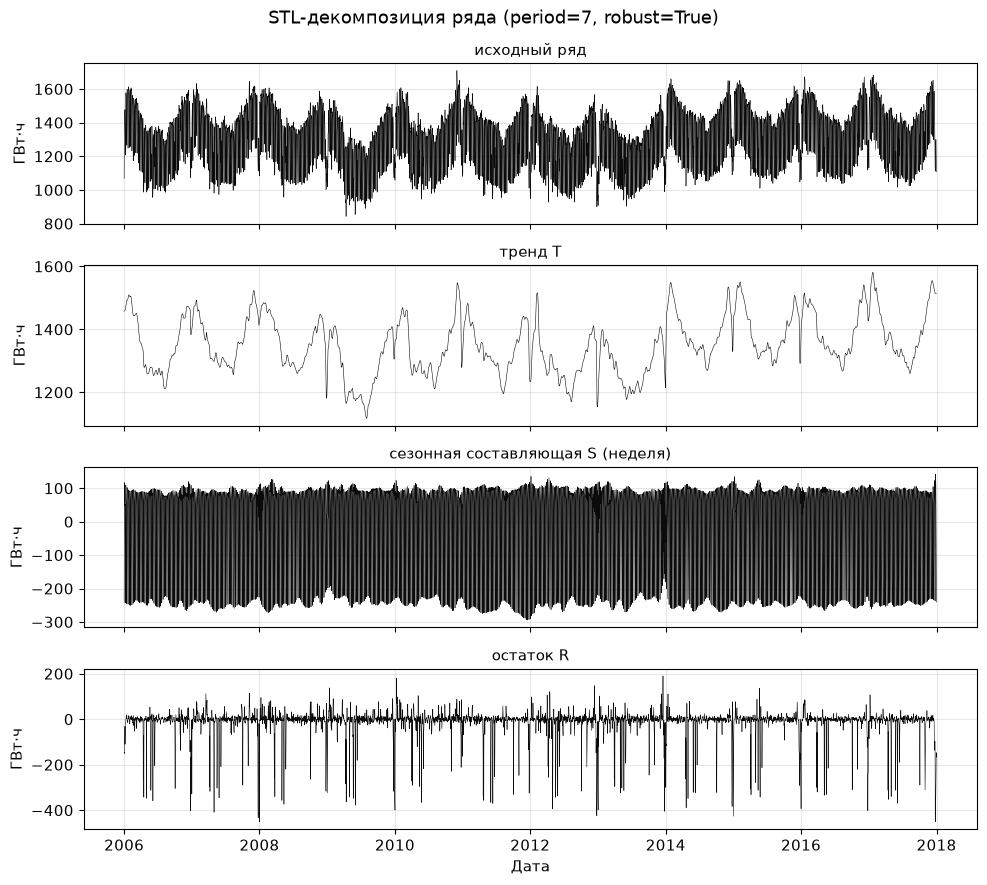

,F_T (тренд),F_S (неделя),"размах недельной составляющей, ГВт·ч","стд остатка, ГВт·ч"
STL,0.703,0.799,436.593,61.23


Date,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
размах S за год,386.7,377.2,399.9,380.5,390.6,413.1,426.7,390.5,391.5,390.9,374.7,403.7
среднее y за год,1339.9,1360.6,1354.0,1259.6,1338.6,1328.3,1283.0,1269.4,1381.3,1384.3,1382.3,1382.8


,остаток,праздник
Date,,
2008-01-01,-451.4,Neujahr
2017-12-26,-450.9,Zweiter Weihnachtstag
2017-12-25,-448.1,Erster Weihnachtstag
2007-12-25,-433.3,Erster Weihnachtstag
2015-01-01,-426.5,Neujahr
2012-12-25,-424.6,Erster Weihnachtstag
2007-05-01,-409.1,Erster Mai
2013-12-25,-405.3,Erster Weihnachtstag


In [34]:
stl = STL(y, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
for ax, (series, title) in zip(axes, [(y, 'исходный ряд'), (stl.trend, 'тренд T'),
                                      (stl.seasonal, 'сезонная составляющая S (неделя)'),
                                      (stl.resid, 'остаток R')]):
    ax.plot(series, color=COLORS['факт'], lw=0.4)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('ГВт·ч')
axes[3].set_xlabel('Дата')
fig.suptitle('STL-декомпозиция ряда (period=7, robust=True)')
fig.tight_layout()
fig.savefig('Рисунки/12_stl.png', dpi=200, bbox_inches='tight')
plt.show()

def strength(component, resid):
    return max(0.0, 1 - np.var(resid) / np.var(component + resid))

stl_info = pd.Series({'F_T (тренд)': strength(stl.trend, stl.resid),
                      'F_S (неделя)': strength(stl.seasonal, stl.resid),
                      'размах недельной составляющей, ГВт·ч': stl.seasonal.max() - stl.seasonal.min(),
                      'стд остатка, ГВт·ч': stl.resid.std()})
display(stl_info.round(3).to_frame('STL').T)
weekly_range = stl.seasonal.groupby(stl.seasonal.index.year).agg(lambda s: s.max() - s.min())
display(pd.DataFrame({'размах S за год': weekly_range, 'среднее y за год': y.groupby(y.index.year).mean()}).round(1).T)
low_resid = stl.resid.nsmallest(8).to_frame('остаток')
low_resid['праздник'] = [hol.get(d, '—') for d in low_resid.index]
display(low_resid.round(1))

STL разложила ряд на тренд, недельную составляющую и остаток. Недельная составляющая почти одинакова все 12 лет: её
размах за год — от 374,7 до 426,7 ГВт·ч, и он не растёт вместе с уровнем ряда (в 2009 г. при среднем 1259,6 —
380,5, в 2015 г. при 1384,3 — 390,9). Поэтому выбрана аддитивная декомпозиция $y = T + S + R$: в мультипликативной
$y = T \cdot S \cdot R$ размах сезонности был бы пропорционален уровню. Сила недельной сезонности $F_S = 0{,}799$,
тренда $F_T = 0{,}703$; тренд при `period=7` включает и годовую волну, отсюда его колебания от зимы к лету.
Стандартное отклонение остатка — 61,2 ГВт·ч, а самые большие отрицательные остатки (от −405,3 до −451,4) приходятся
на Новый год, Рождество и 1 мая: праздники не объясняются ни трендом, ни недельной сезонностью.

В тренд STL с `period=7` попадает и годовая волна — у этой декомпозиции только один сезонный период.
MSTL (STL с несколькими периодами) выделяет недельную и годовую сезонность по отдельности.

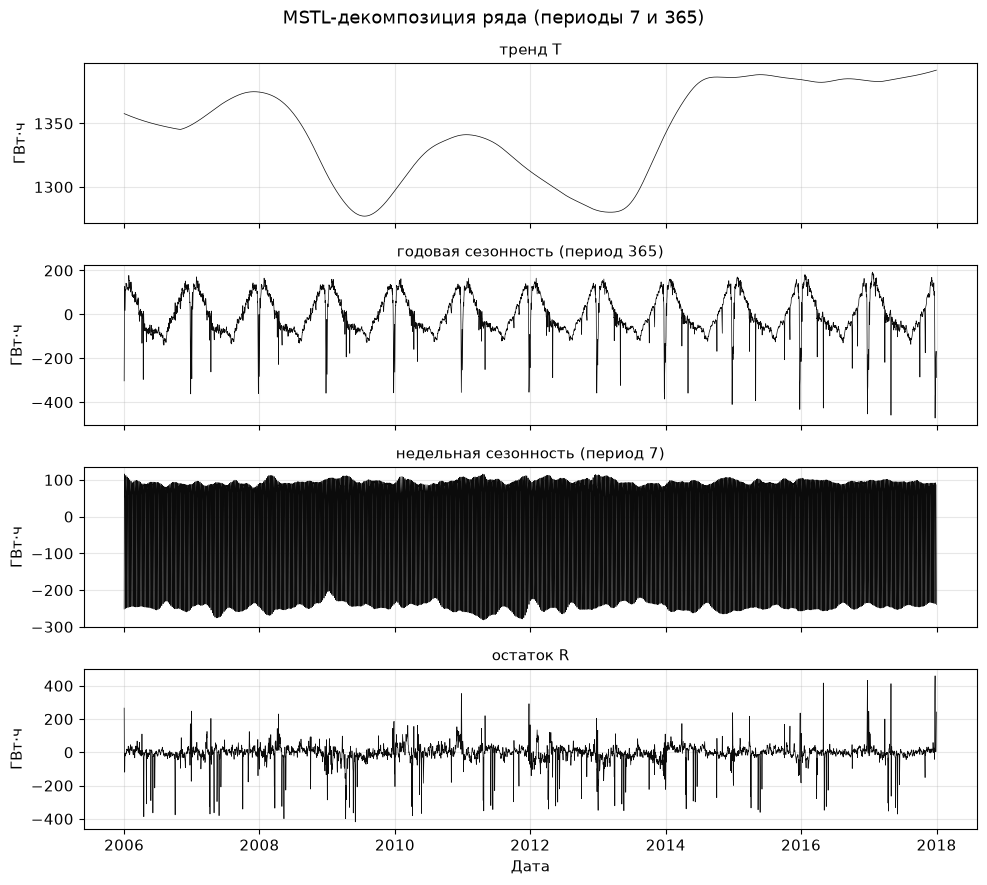

,F_T (тренд),F_S (неделя),F_S (год),"размах годовой составляющей, ГВт·ч","тренд: минимум, ГВт·ч","тренд: максимум, ГВт·ч"
MSTL,0.356,0.813,0.688,665.154,1277.021,1391.962


Date,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
средний тренд MSTL,1349.9,1365.3,1352.2,1286.7,1325.4,1331.0,1295.2,1297.9,1375.5,1386.8,1383.9,1386.3


In [35]:
mstl = MSTL(y, periods=(7, 365), stl_kwargs={'robust': True}).fit()

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
for ax, (series, title) in zip(axes, [(mstl.trend, 'тренд T'),
                                      (mstl.seasonal['seasonal_365'], 'годовая сезонность (период 365)'),
                                      (mstl.seasonal['seasonal_7'], 'недельная сезонность (период 7)'),
                                      (mstl.resid, 'остаток R')]):
    ax.plot(series, color=COLORS['факт'], lw=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('ГВт·ч')
axes[3].set_xlabel('Дата')
fig.suptitle('MSTL-декомпозиция ряда (периоды 7 и 365)')
fig.tight_layout()
fig.savefig('Рисунки/13_mstl.png', dpi=200, bbox_inches='tight')
plt.show()

mstl_info = pd.Series({'F_T (тренд)': strength(mstl.trend, mstl.resid),
                       'F_S (неделя)': strength(mstl.seasonal['seasonal_7'], mstl.resid),
                       'F_S (год)': strength(mstl.seasonal['seasonal_365'], mstl.resid),
                       'размах годовой составляющей, ГВт·ч': mstl.seasonal['seasonal_365'].max() - mstl.seasonal['seasonal_365'].min(),
                       'тренд: минимум, ГВт·ч': mstl.trend.min(),
                       'тренд: максимум, ГВт·ч': mstl.trend.max()})
trend_by_year = mstl.trend.groupby(mstl.trend.index.year).mean()
display(mstl_info.round(3).to_frame('MSTL').T)
display(trend_by_year.round(1).to_frame('средний тренд MSTL').T)
pd.concat([stl_info.rename('STL'), mstl_info.rename('MSTL')], axis=1).round(3).to_csv(
    'Результаты/stl_сила.csv', encoding='utf-8')
trend_by_year.rename('средний тренд MSTL').rename_axis('год').round(1).to_csv('Результаты/mstl_тренд_по_годам.csv', encoding='utf-8')

MSTL отделила годовую сезонность (размах 665,2 ГВт·ч, $F_S = 0{,}688$) от недельной ($F_S = 0{,}813$). Тренд после
этого гладкий и повторяет изменения уровня из таблицы среднегодовых значений: в среднем 1349,9–1365,3 ГВт·ч
в 2006–2008 гг., 1286,7 в 2009 г., 1295,2–1297,9 в 2012–2013 гг. и 1375,5–1386,8 в 2014–2017 гг. Сила тренда
$F_T = 0{,}356$ — небольшая: изменения уровня (весь диапазон тренда 1277,0–1392,0 ГВт·ч) малы по сравнению
с остатком. Праздники и последние дни года видны как резкие выбросы в остатке и в годовой составляющей.

### 6.1. Признаки из STL без утечки

Компоненты STL, посчитанные по всему ряду, как признаки использовать нельзя: LOESS оценивает тренд в точке
$t$ по соседям с обеих сторон, то есть по $y_t, y_{t+1}, \dots$ — в признак попадает будущее.

Использована схема «STL только по прошлому»: для каждого дня $t$ берутся последние 112 дней до $t-1$
включительно, по ним строится STL (`period=7`, `robust=True`), и из этого разложения берутся:
`stl_тренд` — тренд в последний день окна ($t-1$), `stl_сезон` — недельная составляющая того же дня недели,
что и $t$ (позиция $t-7$), `stl_остаток` — остаток в день $t-1$ (насколько необычным был вчерашний день).
Окно 112 дней = 16 недель: в нём по 16 значений на каждый день недели, а сезонное сглаживание STL по
умолчанию (`seasonal=7`) опирается на 7 соседних недель. Признаки дня $t$ зависят только от
$y_{t-112}, \dots, y_{t-1}$, как и обычные лаги, поэтому их можно использовать и на кросс-валидации, и
в рекурсивном прогнозе (там STL на каждом шаге пересчитывается по истории с прогнозами). Функция `stl_features`
считает эти признаки для любого списка дат; в той же ячейке повторена проверка утечки с изменённым $y_{t_0}$.

In [36]:
def stl_features(y, dates, window=112):
    rows = []
    for day in dates:
        past = y.loc[day - pd.Timedelta(days=window):day - pd.Timedelta(days=1)]
        res = STL(past.values, period=7, robust=True).fit()
        rows.append({'stl_тренд': res.trend[-1],
                     'stl_сезон': res.seasonal[-7],
                     'stl_остаток': res.resid[-1]})
    return pd.DataFrame(rows, index=pd.DatetimeIndex(dates))

S = stl_features(y, data.index)
stl_cols = list(S.columns)
X_train_stl = X_train.join(S)
X_test_stl = X_test.join(S)
print('STL-признаки посчитаны для', len(S), 'дней')
display(S.loc['2017-01-01':'2017-01-07'].round(1))

S_changed = stl_features(y_changed, [t0 - pd.Timedelta(days=1), t0, t0 + pd.Timedelta(days=1)])
S_before = S.loc[S_changed.index]
print('Изменились ли STL-признаки (по дням t0−1, t0, t0+1):',
      [bool(not np.allclose(S_changed.loc[d], S_before.loc[d])) for d in S_changed.index])

STL-признаки посчитаны для 4019 дней


,stl_тренд,stl_сезон,stl_остаток
Date,,,
2017-01-01,1155.9,-205.3,207.8
2017-01-02,1179.3,102.0,133.1
2017-01-03,1291.0,100.9,83.9
2017-01-04,1379.8,78.5,-3.1
2017-01-05,1396.0,104.9,-0.1
2017-01-06,1405.3,4.9,1.7
2017-01-07,1417.8,-202.7,-2.1


Изменились ли STL-признаки (по дням t0−1, t0, t0+1): [False, False, True]


STL-признаки посчитаны для всех 4019 дней. Например, для 01.01.2017: `stl_тренд` = 1155,9 — уровень на 31.12.2016
по окну из 112 прошлых дней, `stl_сезон` = −205,3 — недельная составляющая воскресенья, `stl_остаток` = 207,8 —
остаток 31.12.2016. Проверка утечки та же, что для обычных признаков: после изменения $y_{t_0}$ STL-признаки дней
$t_0-1$ и $t_0$ не изменились, изменились только у $t_0+1$.

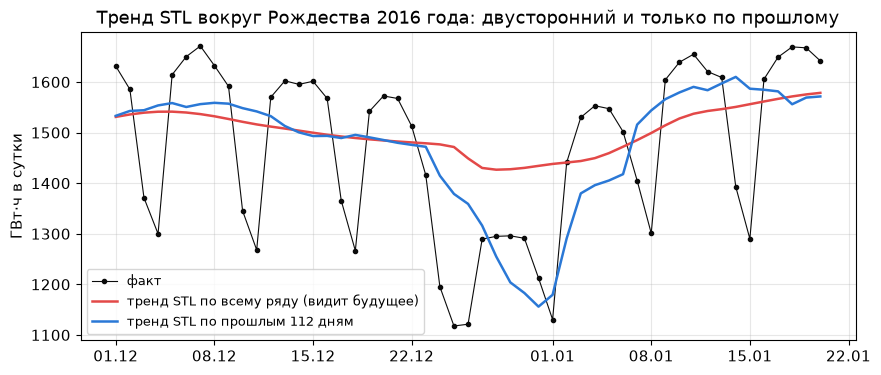

,2016-12-22,2016-12-24,2016-12-27,2016-12-31,2017-01-01,2017-01-04,2017-01-08
факт,1512.7,1195.4,1289.3,1212.6,1130.4,1553.1,1301.0
тренд STL по всему ряду,1480.5,1476.7,1430.1,1434.2,1438.0,1449.5,1499.2
тренд STL по прошлому,1475.7,1414.8,1316.2,1155.9,1179.3,1396.0,1543.8


In [37]:
causal_trend = S['stl_тренд'].copy()
causal_trend.index = causal_trend.index - pd.Timedelta(days=1)
period = slice('2016-12-01', '2017-01-20')
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y.loc[period], color=COLORS['факт'], lw=0.8, marker='.', label='факт')
ax.plot(stl.trend.loc[period], color=COLORS['праздник'], lw=1.8, label='тренд STL по всему ряду (видит будущее)')
ax.plot(causal_trend.loc[period], color=COLORS['Ridge'], lw=1.8, label='тренд STL по прошлым 112 дням')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.set_title('Тренд STL вокруг Рождества 2016 года: двусторонний и только по прошлому')
ax.set_ylabel('ГВт·ч в сутки')
ax.legend(loc='lower left', fontsize=9)
fig.savefig('Рисунки/14_тренд_без_утечки.png', dpi=200, bbox_inches='tight')
plt.show()

compare_dates = pd.to_datetime(['2016-12-22', '2016-12-24', '2016-12-27', '2016-12-31', '2017-01-01',
                                '2017-01-04', '2017-01-08'])
trend_compare = pd.DataFrame({'факт': y.loc[compare_dates],
                              'тренд STL по всему ряду': stl.trend.loc[compare_dates],
                              'тренд STL по прошлому': causal_trend.loc[compare_dates]})
trend_compare.round(1).to_csv('Результаты/тренд_сравнение.csv', encoding='utf-8')
display(trend_compare.round(1).T)

Оценка тренда из признаков дня $t$ относится ко дню $t-1$, поэтому на рисунке она сдвинута на день назад и
сравнивается с двусторонним трендом того же дня.
Двусторонний тренд (по всему ряду) в рождественские дни почти не опускается (1476,7 ГВт·ч на 24.12, 1430,1 на 27.12)
и 31.12–01.01 держится на уровне 1434,2–1438,0, хотя все предшествующие дни низкие: LOESS учитывает и январские
значения, которые идут следом. Тренд только по прошлому опускается до 1155,9 к 31.12 и поднимается к рабочему уровню
лишь после того, как туда вернулся сам ряд (1396,0 на 04.01, 1543,8 на 08.01). В реальном прогнозе на 01.01.2017
январские данные неизвестны, поэтому признаки из двустороннего тренда — утечка.

### 6.2. Улучшают ли STL-признаки прогноз

Честное сравнение: те же фолды `TimeSeriesSplit`, та же сетка гиперпараметров (подбор заново для набора
признаков с STL), тот же тест 2017 и тот же рекурсивный прогноз на 14 дней.

In [38]:
ridge_stl_grid = GridSearchCV(make_ridge(num_features + stl_cols), {'model__alpha': np.logspace(-3, 3, 13)},
                              cv=tscv, scoring='neg_mean_absolute_error')
ridge_stl_grid.fit(X_train_stl, y_train)
hgb_stl_grid = GridSearchCV(HistGradientBoostingRegressor(random_state=RANDOM_STATE), hgb_params,
                            cv=tscv, scoring='neg_mean_absolute_error')
hgb_stl_grid.fit(X_train_stl, y_train)
models_stl = {'Ridge': ridge_stl_grid.best_estimator_, 'Бустинг': hgb_stl_grid.best_estimator_}
print('Ridge + STL: alpha =', ridge_stl_grid.best_params_['model__alpha'])
print('Бустинг + STL:', hgb_stl_grid.best_params_)

cv_folds_stl = pd.DataFrame(index=fold_names)
for name, grid_search in [('Ridge', ridge_grid), ('Ridge + STL', ridge_stl_grid),
                          ('Бустинг', hgb_grid), ('Бустинг + STL', hgb_stl_grid)]:
    cv_folds_stl[name] = [-grid_search.cv_results_[f'split{k}_test_score'][grid_search.best_index_]
                          for k in range(5)]
cv_folds_stl.loc['среднее'] = cv_folds_stl.mean()
cv_folds_stl.round(2).to_csv('Результаты/cv_mae_stl.csv', encoding='utf-8')
display(cv_folds_stl.round(2))
print('Корреляция stl_тренд и среднее_7 на train:',
      round(X_train_stl['stl_тренд'].corr(X_train_stl['среднее_7']), 3))

Ridge + STL: alpha = 0.001
Бустинг + STL: {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 15, 'min_samples_leaf': 40}


,Ridge,Ridge + STL,Бустинг,Бустинг + STL
фолд 1 (2012),27.23,27.02,29.31,29.87
фолд 2 (2013),22.59,22.35,23.25,23.66
фолд 3 (2014),20.95,21.06,26.62,28.05
фолд 4 (2015),21.25,21.26,17.30,17.86
фолд 5 (2016),20.83,20.90,18.11,17.67
среднее,22.57,22.52,22.92,23.42


Корреляция stl_тренд и среднее_7 на train: 0.973


На кросс-валидации STL-признаки почти ничего не меняют. У Ridge средняя MAE 22,52 против 22,57 без них
(−0,05 ГВт·ч; на двух фолдах лучше, на трёх хуже), у бустинга 23,42 против 22,92 — хуже на 0,50 (лучше только
в 2016 г.). Обе разницы намного меньше разброса MAE между фолдами. При этом `stl_тренд` почти повторяет уже
имеющееся скользящее среднее за 7 дней: их корреляция на train — 0,973.

In [39]:
horizon_test_stl = {name: evaluate_horizon(model, test_starts, use_stl=True) for name, model in models_stl.items()}

rows = []
for name in models:
    for variant, model, X_te, res in [('без STL', models[name], X_test, horizon_test[name]),
                                      ('с STL', models_stl[name], X_test_stl, horizon_test_stl[name])]:
        one = metrics(y_test, model.predict(X_te))
        hz = metrics(res['факт'], res['прогноз'])
        rows.append({'модель': name, 'признаки': variant,
                     'MAE на CV': cv_folds_stl.loc['среднее', name if variant == 'без STL' else f'{name} + STL'],
                     'MSE тест (1 шаг)': one['MSE'], 'MAE тест (1 шаг)': one['MAE'],
                     'MAPE тест (1 шаг), %': one['MAPE, %'], 'WAPE тест (1 шаг), %': one['WAPE, %'],
                     'MAE тест (14 дней)': hz['MAE'], 'WAPE тест (14 дней), %': hz['WAPE, %']})
stl_compare = pd.DataFrame(rows).set_index(['модель', 'признаки'])
stl_compare.to_csv('Результаты/stl_сравнение.csv', encoding='utf-8')
display(stl_compare.round(2))

MAE на CV  MSE тест (1 шаг)  MAE тест (1 шаг)  \
модель  признаки                                                  
Ridge   без STL       22.57            919.68             20.14   
        с STL         22.52            928.97             20.00   
Бустинг без STL       22.92            729.21             18.49   
        с STL         23.42            713.07             18.53   

                  MAPE тест (1 шаг), %  WAPE тест (1 шаг), %  \
модель  признаки                                               
Ridge   без STL                   1.51                  1.46   
        с STL                     1.50                  1.45   
Бустинг без STL                   1.37                  1.34   
        с STL                     1.38                  1.34   

                  MAE тест (14 дней)  WAPE тест (14 дней), %  
модель  признаки                                              
Ridge   без STL                29.09                    2.10  
        с STL                  29.47                    2.13  
Бустинг без STL                28.12                    2.03  
        с STL                  27.92                    2.02

На тесте картина та же. На 1 шаг: MAE Ridge 20,00 против 20,14, бустинга 18,53 против 18,49; MSE у Ridge с STL
хуже (928,97 против 919,68), у бустинга лучше (713,07 против 729,21). На горизонте 14 дней Ridge с STL хуже
(29,47 против 29,09), бустинг чуть лучше (27,92 против 28,12). Все изменения MAE не больше 0,4 ГВт·ч, изменения
MSE — около 1–2 %, и знак у них разный для разных моделей и метрик.

**Вывод:** признаки из STL-декомпозиции, посчитанные честно, только по прошлому, качество прогноза не улучшают;
новой информации по сравнению с лагами, скользящими статистиками и календарём в них мало (корреляция
`stl_тренд` со `среднее_7` — 0,973).

**Для сравнения — что было бы с утечкой.** Те же три признака, но взятые из STL всего ряда (тренд и остаток
на $t-1$, сезонность на $t-7$). Двусторонний LOESS в этих значениях уже «видел» $y_t$ и следующие дни.
Так делать нельзя — расчёт приведён только для того, чтобы показать, насколько утечка искажает оценку.

In [40]:
leak = pd.DataFrame({'stl_тренд': stl.trend.shift(1), 'stl_сезон': stl.seasonal.shift(7),
                     'stl_остаток': stl.resid.shift(1)})
X_train_leak = X_train.join(leak)
X_test_leak = X_test.join(leak)
rows = []
for name, model in models_stl.items():
    cv_leak = -cross_validate(model, X_train_leak, y_train, cv=tscv, scoring='neg_mean_absolute_error')['test_score']
    fitted = clone(model).fit(X_train_leak, y_train)
    rows.append({'модель': name, 'MAE на CV (STL всего ряда)': cv_leak.mean(),
                 'MAE на CV (STL по прошлому)': cv_folds_stl.loc['среднее', f'{name} + STL'],
                 'MAE тест (STL всего ряда)': mean_absolute_error(y_test, fitted.predict(X_test_leak)),
                 'MAE тест (STL по прошлому)': stl_compare.loc[(name, 'с STL'), 'MAE тест (1 шаг)']})
leak_table = pd.DataFrame(rows).set_index('модель')
leak_table.to_csv('Результаты/stl_утечка.csv', encoding='utf-8')
display(leak_table.round(2))

,MAE на CV (STL всего ряда),MAE на CV (STL по прошлому),MAE тест (STL всего ряда),MAE тест (STL по прошлому)
модель,,,,
Ridge,19.56,22.52,18.14,20.00
Бустинг,20.32,23.42,16.67,18.53


С компонентами STL всего ряда MAE на кросс-валидации «улучшилась» бы до 19,56 у Ridge и 20,32 у бустинга — на 13 %
ниже честных 22,52 и 23,42, а на тесте — до 18,14 и 16,67 вместо 20,00 и 18,53. Такой выигрыш ложный: признаки
содержат значения ряда из будущего, которых в момент прогноза нет. Поэтому в работе компоненты декомпозиции
считаются только по прошлому.

## Сохранение итоговых чисел

In [41]:
summary = {
    'строк': int(len(df)), 'период': [str(df.index.min().date()), str(df.index.max().date())],
    'потребление': {k: round(float(v), 1) for k, v in y.describe().items() if k != 'count'},
    'признаков': len(features), 'train_дней': int(len(X_train)), 'test_дней': int(len(X_test)),
    'train_период': [str(X_train.index.min().date()), str(X_train.index.max().date())],
    'ridge_alpha': float(best_alpha), 'hgb_параметры': dict(hgb_grid.best_params_),
    'hgb_сочетаний': int(len(grid_table)),
    'ridge_stl_alpha': float(ridge_stl_grid.best_params_['model__alpha']),
    'hgb_stl_параметры': dict(hgb_stl_grid.best_params_),
    'H': H, 'начал_прогноза_тест': int(len(test_starts)), 'начал_прогноза_train': int(len(train_starts)),
    'stl_окно_дней': 112,
    'корр_stl_тренд_среднее_7': round(float(X_train_stl['stl_тренд'].corr(X_train_stl['среднее_7'])), 3),
    'смещение_тест': {k.replace('ошибка ', ''): round(float(v), 2) for k, v in bias_month.loc['весь год'].items()},
    'автокорреляция': {str(k): round(float(v), 3) for k, v in acf_values.items()},
}
with open('Результаты/сводка.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=1)
print(json.dumps(summary, ensure_ascii=False, indent=1))

{
 "строк": 4383,
 "период": [
  "2006-01-01",
  "2017-12-31"
 ],
 "потребление": {
  "mean": 1338.7,
  "std": 165.8,
  "min": 842.4,
  "25%": 1217.9,
  "50%": 1367.1,
  "75%": 1457.8,
  "max": 1709.6
 },
 "признаков": 28,
 "train_дней": 3654,
 "test_дней": 365,
 "train_период": [
  "2006-12-31",
  "2016-12-31"
 ],
 "ridge_alpha": 0.001,
 "hgb_параметры": {
  "learning_rate": 0.05,
  "max_iter": 400,
  "max_leaf_nodes": 15,
  "min_samples_leaf": 40
 },
 "hgb_сочетаний": 36,
 "ridge_stl_alpha": 0.001,
 "hgb_stl_параметры": {
  "learning_rate": 0.05,
  "max_iter": 400,
  "max_leaf_nodes": 15,
  "min_samples_leaf": 40
 },
 "H": 14,
 "начал_прогноза_тест": 352,
 "начал_прогноза_train": 353,
 "stl_окно_дней": 112,
 "корр_stl_тренд_среднее_7": 0.973,
 "смещение_тест": {
  "Ridge": 3.69,
  "Бустинг": 0.01
 },
 "автокорреляция": {
  "1": 0.589,
  "2": 0.166,
  "3": 0.048,
  "6": 0.51,
  "7": 0.845,
  "8": 0.485,
  "14": 0.769,
  "21": 0.743,
  "28": 0.719,
  "182": 0.392,
  "364": 0.75,
  "365

Основные числа сохранены в `Результаты/сводка.json`, таблицы — в CSV-файлах той же папки; по ним
составлен отчёт.

## Выводы

1. **Загрузка и визуализация.** Ряд — 4383 суток (2006–2017) без пропусков и повторов. Монотонного тренда нет, есть
   изменения уровня (минимум 1259,6 ГВт·ч в 2009 г., скачок +111,9 ГВт·ч в 2014 г.). Сезонность двух видов:
   недельная (медиана воскресенья 1092,9 против 1399,4–1431,5 в будни, автокорреляция на лаге 7 — 0,845) и годовая
   (медиана февраля 1503,5 против 1291,9 в августе). Выбросы — праздники и последняя неделя декабря.
2. **Признаки.** 28 признаков только из прошлого: календарь, лаги 1–7, 14, 21, 28, 364 и скользящие статистики за
   7 и 30 дней по сдвинутому ряду. Проверка с изменением $y_{t_0}$ подтвердила отсутствие утечки.
3. **Разделение и кросс-валидация.** Train — 2006–2016 гг. (3654 дня), test — 2017 г. (365 дней); `TimeSeriesSplit`
   с расширяющимся окном, 5 фолдов по 365 дней. Скользящее окно в 3 года оказалось хуже (MAE 28,76 и 36,02 против
   22,57 и 22,92).
4. **Модели и горизонт.** Ridge ($\alpha = 0{,}001$) и градиентный бустинг (400 деревьев) на тесте ошибаются на
   20,14 и 18,49 ГВт·ч (WAPE 1,46 % и 1,34 %) против 54,10 ГВт·ч (3,91 %) у сезонно-наивного прогноза.
   Рекурсивный прогноз на 14 дней: MAE растёт от 19,3 и 17,7 на 1-м шаге до 33,9 и 33,5 на 14-м; WAPE на всём
   горизонте — 2,10 % и 2,03 % против 3,86 % у сезонно-наивного.
5. **Оценка качества.** В обычные дни MAE 15–18 ГВт·ч, в праздники, рядом с ними, в праздники части земель и
   24–31 декабря — в 2,7–4,6 раза больше. Бустинг на train ошибается заметно меньше, чем на тесте (13,56 против
   18,49), — признак переобучения; при скачке уровня (2014 г.) он ошибался сильнее Ridge.
6. **Декомпозиция.** STL: сила недельной сезонности 0,799, размах недельной составляющей почти постоянен, поэтому
   декомпозиция аддитивная; MSTL дополнительно выделила годовую сезонность (размах 665,2 ГВт·ч) и гладкий тренд.
   Признаки из STL, посчитанные только по прошлому, качество не улучшили (изменения MAE до 0,5 ГВт·ч разного знака);
   компоненты STL всего ряда дали бы ложное улучшение на 13 % — это эффект утечки.

**Ограничения.** Модель использует только сам ряд и календарь: в ней нет внешних данных (например, о погоде),
праздников отдельных земель, «мостиков» между праздником и выходными и признака последней недели декабря — как раз
в такие дни ошибки наибольшие. Ошибка рекурсивного прогноза накапливается с шагом горизонта. Тест — один год со
стабильным уровнем; при резком изменении уровня, как в 2014 г., ошибки были бы больше, особенно у бустинга.
Модель даёт точечный прогноз без интервала неопределённости.